# Bayesian Optimization — Function 6 (5D, Improved)

This notebook runs one step of Bayesian Optimization on a **5-dimensional** black-box function.

### Improvements over the original F6 script

| Area | Original | Improved |
|---|---|---|
| **Seed** | None | `np.random.default_rng(42)` |
| **Data path** | Hardcoded Windows path | `pathlib.Path(".")` — portable |
| **Data loading** | Loads all 8 functions, uses only F6 | Loads F6 only |
| **y transform** | None | None needed (all negative, range -2.57 to -0.71, well-scaled) |
| **Kernel** | RBF | Matérn ν=2.5 |
| **xi** | Fixed at 0.1 | Adaptive (starts at 0.1, decays) |
| **Sampling** | 150k pure random | 80k Sobol quasi-random (tuned for 5D) |
| **L-BFGS-B starts** | 5 | 13 |
| **Acquisition** | EI only | EI or UCB (switchable) |
| **Structure** | One-shot script | Full BO loop with history tracking |
| **Visualization** | None | 2D slice plots (all 10 dimension pairs, 2x5 grid) + convergence plot |

## 1. Imports & Configuration

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
from itertools import combinations

from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import Matern, ConstantKernel as C, WhiteKernel
from scipy.stats import norm, qmc
from scipy.optimize import minimize

# ── SVM: Classify high vs low regions ────────────────────────────────────────
from sklearn.svm import SVC
from sklearn.preprocessing import StandardScaler

# ── Neural Network: MC-Dropout surrogate ─────────────────────────────────────
import torch
import torch.nn as nn
import torch.optim as optim

import warnings
from sklearn.exceptions import ConvergenceWarning
warnings.filterwarnings("ignore", category=ConvergenceWarning)

# ── Reproducibility ───────────────────────────────────────────────────────────
SEED = 42
rng  = np.random.default_rng(SEED)
torch.manual_seed(SEED)

## 2. Data Loading

The original script loaded all 8 functions simultaneously but only used F6. Cleaned up to load F6 only.

F6 is **5-dimensional** with output values ranging from approximately **-2.57 to -0.71**. Two things to note:

- **All outputs are negative** — this is perfectly fine for Bayesian optimization. We are still maximising (toward zero, i.e. least negative), and the GP handles negative y values natively with `normalize_y=True`.
- **The range is well-scaled** (about 1.86 units wide) — no log-transform is needed. The GP will fit the raw values without calibration issues.

> **Tip:** in later iterations, if the suggested point repeatedly hits a boundary (as `x₄=1.0` did in the original), it may indicate the true optimum lies near or beyond that boundary, or that the GP's uncertainty is highest there. Watching the slice plots across iterations will help distinguish the two cases.

In [2]:
# ── Portable data loading ─────────────────────────────────────────────────────
# Place initial_inputs.npy / initial_outputs.npy next to this notebook,
# OR change DATA_DIR to wherever the F6 data lives.
DATA_DIR = Path("C:\\Users\\fakep\\OneDrive\\Bureau\\CAPSTONE\\function_6\\")    # <-- edit if needed

X = np.load(DATA_DIR / "initial_inputs.npy")
y = np.load(DATA_DIR / "initial_outputs.npy")

n_dim = X.shape[1]
print(f"Loaded {len(y)} observations, {n_dim} dimensions.")
print(f"y range : [{y.min():.4f}, {y.max():.4f}]  (all negative — maximising toward zero)")
print(f"Current best y = {y.max():.6f}  (at index {y.argmax()})")

Loaded 20 observations, 5 dimensions.
y range : [-2.5712, -0.7143]  (all negative — maximising toward zero)
Current best y = -0.714265  (at index 0)


## 3. Gaussian Process Model

We use a **Matérn ν=2.5 kernel** instead of the original RBF:
- **RBF** assumes infinite differentiability — often an overly smooth assumption
- **Matérn 5/2** assumes only twice differentiability, which generalises better for real-world black-box functions

In 5D the GP must generalise across a larger space with the same number of initial points. The original script used a wider RBF length scale upper bound (`1e4` instead of `1e2` used in F2–F4) — a sensible adjustment for higher dimensions that we preserve here.

In [3]:
def build_gp(n_dim: int) -> GaussianProcessRegressor:
    kernel = (
        C(1.0, constant_value_bounds=(1e-3, 1e5))
        * Matern(length_scale=[1.0] * n_dim,
                 length_scale_bounds=(1e-3, 1e4),   # wider bound preserved from original
                 nu=2.5)
        + WhiteKernel(noise_level=1e-5,
                      noise_level_bounds=(1e-7, 1e-1))
    )
    return GaussianProcessRegressor(
        kernel=kernel,
        n_restarts_optimizer=25,
        alpha=1e-6,
        normalize_y=True,
    )

## 4. Acquisition Functions

Acquisition functions decide **where to sample next** by balancing exploration (uncertain regions) and exploitation (promising regions).

### Expected Improvement (EI)
$$EI(x) = (\mu(x) - y_{max} - \xi) \cdot \Phi(Z) + \sigma(x) \cdot \phi(Z), \quad Z = \frac{\mu(x) - y_{max} - \xi}{\sigma(x)}$$
where `ξ` (xi) controls the exploration-exploitation trade-off. Since all F6 outputs are negative, `y_max` is the least negative value (e.g. `-0.71`), and EI correctly targets points predicted to exceed it.

### Upper Confidence Bound (UCB)
$$UCB(x) = \mu(x) + \kappa \cdot \sigma(x)$$

### Adaptive xi
We preserve `xi_init=0.1` from the original — appropriate for a 5D space. The decay gradually shifts toward exploitation as more observations accumulate. In 5D, exploration remains important for longer than in 2D–3D, so the decay rate of 0.85 is intentionally moderate.

In [4]:
def expected_improvement(X_cand, gp, y_max, xi=0.01):
    """Expected Improvement — higher is better."""
    X_cand = np.atleast_2d(X_cand)
    mu, sigma = gp.predict(X_cand, return_std=True)
    sigma = np.maximum(sigma, 1e-8)
    imp   = mu - y_max - xi
    Z     = imp / sigma
    ei    = imp * norm.cdf(Z) + sigma * norm.pdf(Z)
    ei[sigma <= 1e-8] = 0.0
    return ei


def upper_confidence_bound(X_cand, gp, kappa=2.576):
    """UCB — higher kappa = more exploration."""
    X_cand = np.atleast_2d(X_cand)
    mu, sigma = gp.predict(X_cand, return_std=True)
    return mu + kappa * sigma


def adaptive_xi(iteration: int, xi_init=0.1, decay=0.85) -> float:
    """Decay xi over iterations for a smooth exploration -> exploitation shift."""
    return max(xi_init * (decay ** iteration), 1e-4)

## 5. Next-Point Suggestion

We find the next point to evaluate in three steps:

1. **Sobol sampling** — generate `n_sobol=80,000` quasi-random candidates in [0,1]⁵. The original used 150k pure random samples; 80k Sobol points provide superior coverage thanks to the low-discrepancy property of Sobol sequences, while being computationally lighter.
2. **Score & rank** — evaluate the acquisition function on all candidates and keep the top `n_best=13`.
3. **Local optimisation** — run L-BFGS-B from each of the 13 starting points. 13 restarts is scaled appropriately for 5D — between the 12 used for 4D and the 15 used for 8D.

> If the suggested point repeatedly hits a boundary across iterations, consider whether the true optimum may lie near that boundary, or switch to UCB (`ACQ = "ucb"`) which more aggressively explores uncertain corners.

In [5]:
def suggest_next_point(
    gp,
    y_max,
    n_dim,
    xi=0.01,
    n_sobol=80_000,   # tuned for 5D
    n_best=13,        # scaled between 4D (12) and 8D (15)
    acq="ei",
    kappa=2.576,
    seed=None,
):
    # Step 1 — Sobol candidates
    sampler = qmc.Sobol(d=n_dim, scramble=True, seed=seed)
    X_cand  = sampler.random(n_sobol)

    # Step 2 — Score
    if acq == "ucb":
        scores = upper_confidence_bound(X_cand, gp, kappa=kappa)
    else:
        scores = expected_improvement(X_cand, gp, y_max, xi=xi)

    # Step 3 — Local optimisation from top-n_best starts
    starts = X_cand[np.argsort(scores)[-n_best:]]
    bounds = [(0, 1)] * n_dim

    if acq == "ucb":
        obj = lambda x: -upper_confidence_bound(x, gp, kappa=kappa).item()
    else:
        obj = lambda x: -expected_improvement(x, gp, y_max, xi=xi).item()

    best_x, best_score = None, -np.inf
    for x0 in starts:
        res = minimize(obj, x0=x0, bounds=bounds, method="L-BFGS-B")
        if -res.fun > best_score:
            best_score = -res.fun
            best_x     = res.x

    return best_x, best_score

## 6. 5D Slice Visualisation Helper

In 5 dimensions there are **10 possible dimension pairs** (5 choose 2). We render all 10 in a **2×5 grid**, fixing the three remaining dimensions at `x_next`'s values in each panel.

With 10 panels, each individual plot is smaller — resolution is reduced to 80 pixels per axis to keep render time manageable while still clearly showing the acquisition landscape structure.

As with F3/F4/F5, observed points are projected onto each 2D plane with **opacity proportional to proximity** to all three fixed dimension values — points far from the slice plane fade out, reducing visual clutter in the 5D case.

In [6]:
def plot_slices_5d(gp, X_obs, x_next, acq_fn, iteration, acq_label="EI"):
    """
    2x5 grid of acquisition function slice plots covering all 10 dimension pairs.
    Each panel fixes the three non-plotted dimensions at x_next's values.
    """
    resolution = 80    # reduced to keep 10-panel render time reasonable
    grid_1d    = np.linspace(0, 1, resolution)
    G1, G2     = np.meshgrid(grid_1d, grid_1d)
    flat1      = G1.ravel()
    flat2      = G2.ravel()

    dim_labels = ["x1", "x2", "x3", "x4", "x5"]
    dim_pairs  = list(combinations(range(5), 2))   # all 10 pairs

    fig, axes = plt.subplots(2, 5, figsize=(22, 9))
    axes      = axes.ravel()
    fig.suptitle(
        f"Bayesian Optimization - F6  |  Iteration {iteration}  |  "
        f"Acquisition ({acq_label}) - all dimension pairs",
        fontsize=12
    )

    for ax, (d0, d1) in zip(axes, dim_pairs):
        fixed_dims = [d for d in range(5) if d not in (d0, d1)]

        # Build grid: sweep d0 and d1, fix others at x_next values
        X_grid        = np.tile(x_next, (resolution * resolution, 1))
        X_grid[:, d0] = flat1
        X_grid[:, d1] = flat2

        acq_vals = acq_fn(X_grid).reshape(resolution, resolution)

        im = ax.contourf(G1, G2, acq_vals, levels=40, cmap="inferno")
        fig.colorbar(im, ax=ax, shrink=0.8)

        # Project observed points; opacity = proximity to all fixed dim values
        dist   = np.mean([np.abs(X_obs[:, fd] - x_next[fd]) for fd in fixed_dims], axis=0)
        alphas = np.clip(1.0 - dist / 0.3, 0.1, 1.0)
        for xi_obs, yi_obs, a in zip(X_obs[:, d0], X_obs[:, d1], alphas):
            ax.scatter(xi_obs, yi_obs, c="white", edgecolors="black",
                       s=20, alpha=float(a), zorder=5)

        # Suggested next point projection
        ax.scatter(x_next[d0], x_next[d1], c="red", marker="*",
                   s=200, zorder=6, label="Next point")

        fix_str = ", ".join(f"{dim_labels[fd]}={x_next[fd]:.2f}" for fd in fixed_dims)
        ax.set_title(f"{dim_labels[d0]}-{dim_labels[d1]}\n({fix_str})", fontsize=8)
        ax.set_xlabel(dim_labels[d0], fontsize=8)
        ax.set_ylabel(dim_labels[d1], fontsize=8)
        ax.tick_params(labelsize=7)

    axes[-1].legend(loc="upper right", fontsize=7)
    plt.tight_layout()
    plt.savefig(f"bo_f6_iter_{iteration:03d}.png", dpi=150, bbox_inches="tight")
    plt.show()

## 7. Bayesian Optimization Loop

The full BO loop follows this cycle each iteration:

```
Fit GP  ->  Compute xi  ->  Maximise acquisition  ->  Suggest x_next
         ^                                                  |
         +---- Append (x_next, y_new) to dataset  <--------+
                   (you evaluate y_new externally)
```

**To use this loop:**
1. Run the cell — it will print the suggested point and render the 10-panel slice plot
2. Evaluate the real function at `x_next` to get `y_new`
3. Uncomment the lines under `PLUG YOUR EVALUATOR HERE`
4. Set `N_ITER > 1` and re-run for multi-step optimization

> **Note:** no log-transform is applied. Append the raw `y_new` value directly to `y_obs`. Since all F6 outputs are negative, `y_new` should also be negative — if you observe a positive value, something unexpected has occurred and is worth investigating.

C:\Users\fakep\AppData\Local\Temp\ipykernel_22264\1562328627.py:14: UserWarning: The balance properties of Sobol' points require n to be a power of 2.
  X_cand  = sampler.random(n_sobol)



  Iteration   1  |  xi = 0.10000  |  acq = EI
  Current best y  : -0.714265  (maximising toward zero)
  ✅ Suggested x CAPSTONE       : 0.460174-0.237678-0.576491-1.0-0.0
  Suggested x     : [0.460174, 0.237678, 0.576491, 1.0, 0.0]
  Acq. score      : 0.402298


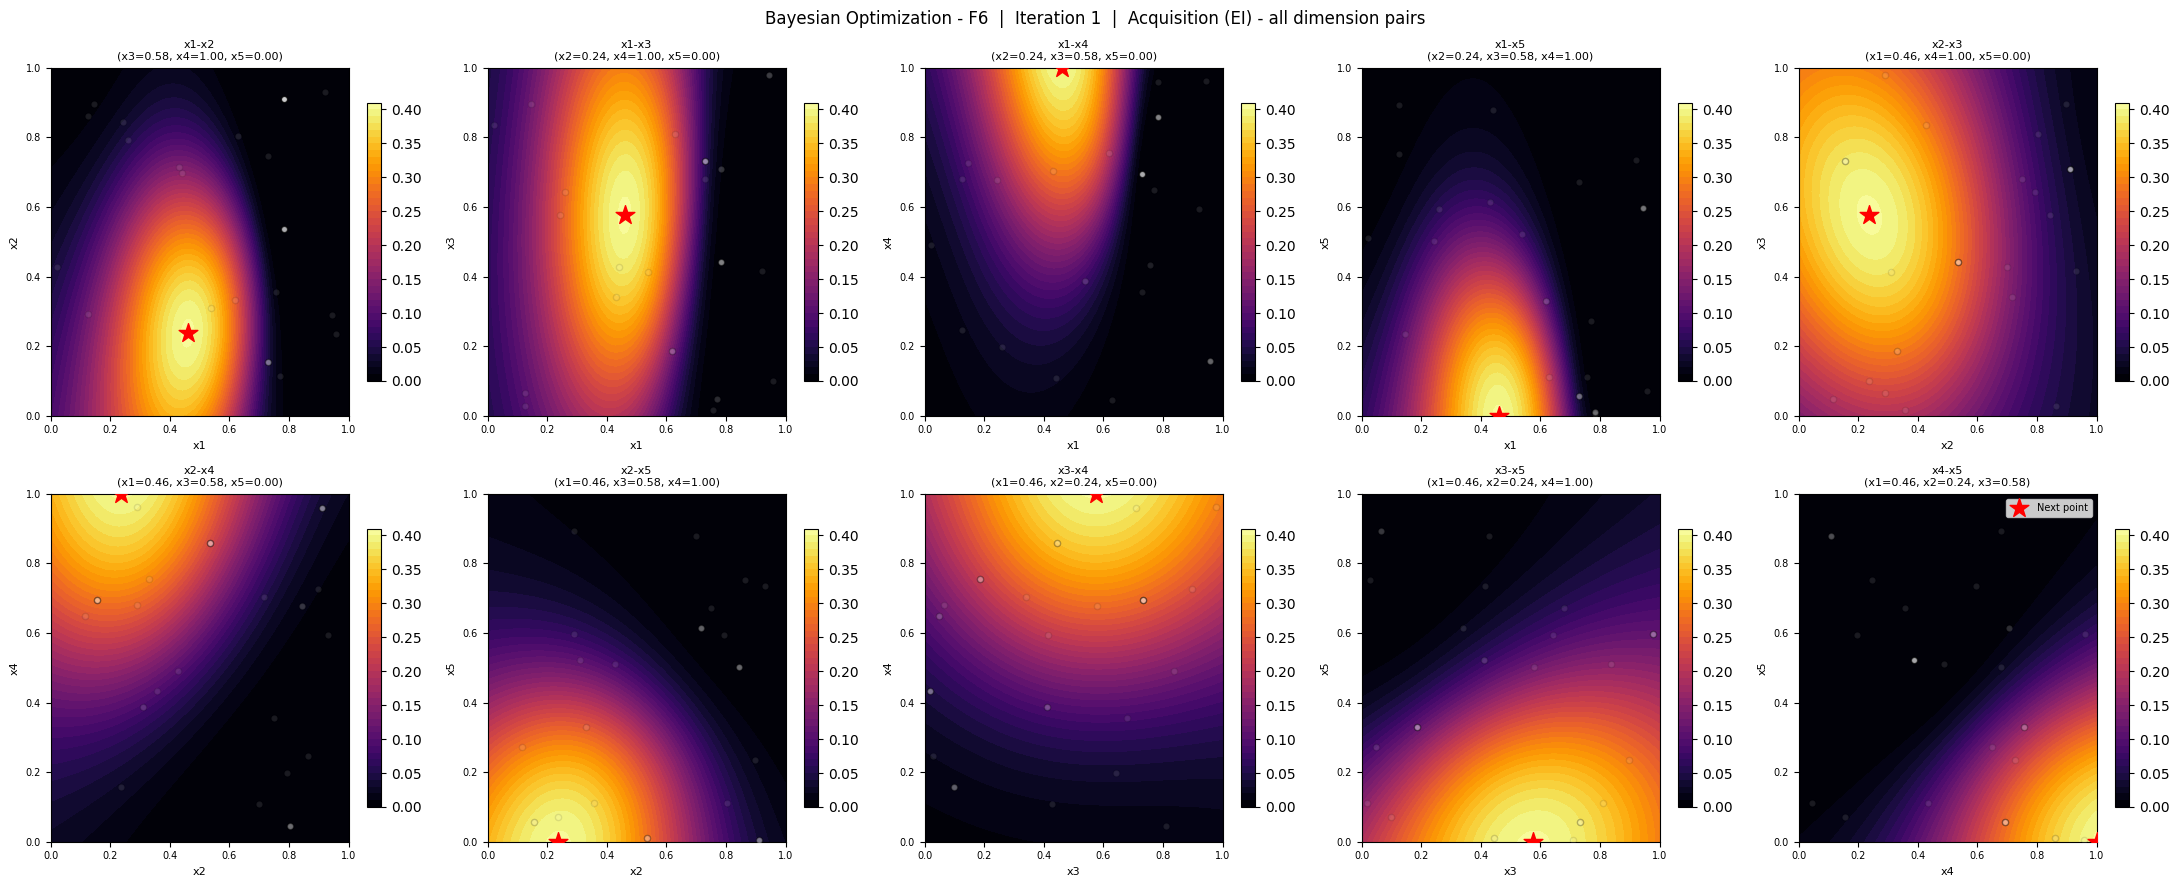

C:\Users\fakep\AppData\Local\Temp\ipykernel_22264\1562328627.py:14: UserWarning: The balance properties of Sobol' points require n to be a power of 2.
  X_cand  = sampler.random(n_sobol)



  Iteration   2  |  xi = 0.08500  |  acq = EI
  Current best y  : -0.475132  (maximising toward zero)
  ✅ Suggested x CAPSTONE       : 0.40169-0.0-1.0-1.0-0.0
  Suggested x     : [0.40169, 0.0, 1.0, 1.0, 0.0]
  Acq. score      : 0.144294


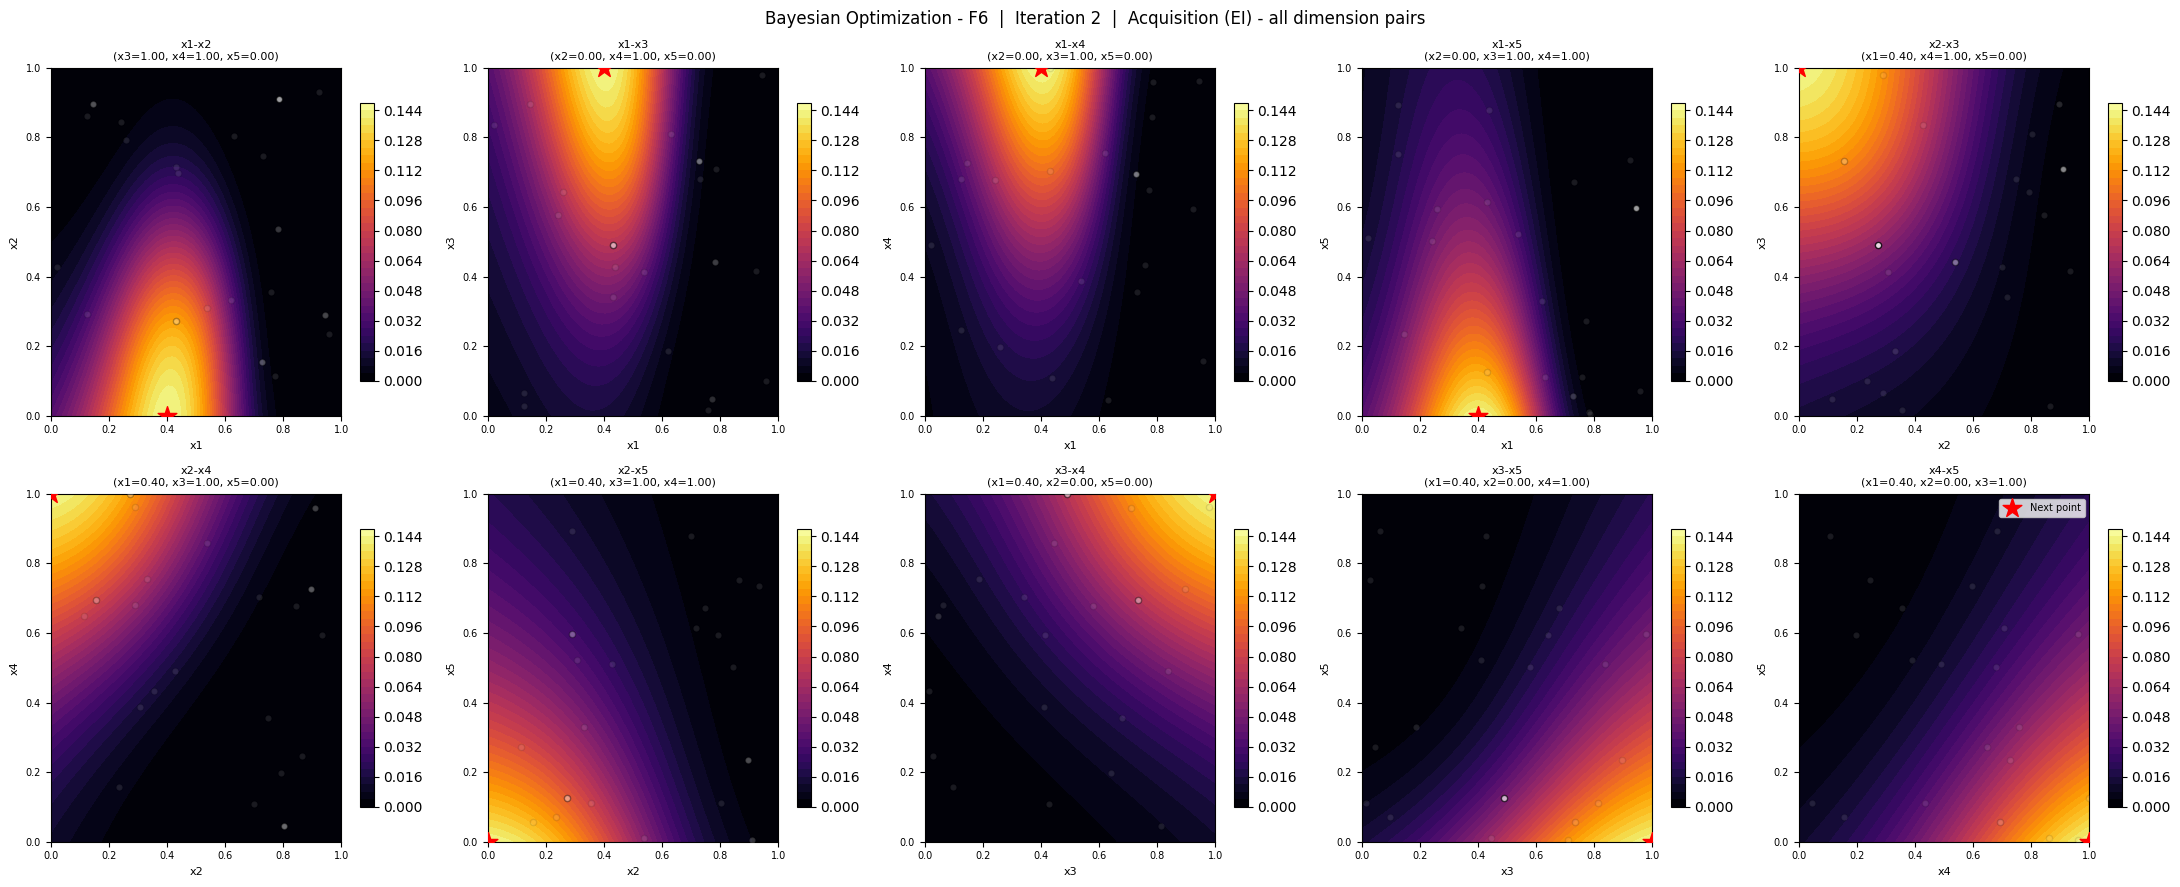

C:\Users\fakep\AppData\Local\Temp\ipykernel_22264\1562328627.py:14: UserWarning: The balance properties of Sobol' points require n to be a power of 2.
  X_cand  = sampler.random(n_sobol)



  Iteration   3  |  xi = 0.07225  |  acq = EI
  Current best y  : -0.475132  (maximising toward zero)
  ✅ Suggested x CAPSTONE       : 0.505591-0.38492-0.335065-0.935881-0.0
  Suggested x     : [0.505591, 0.38492, 0.335065, 0.935881, 0.0]
  Acq. score      : 0.045650


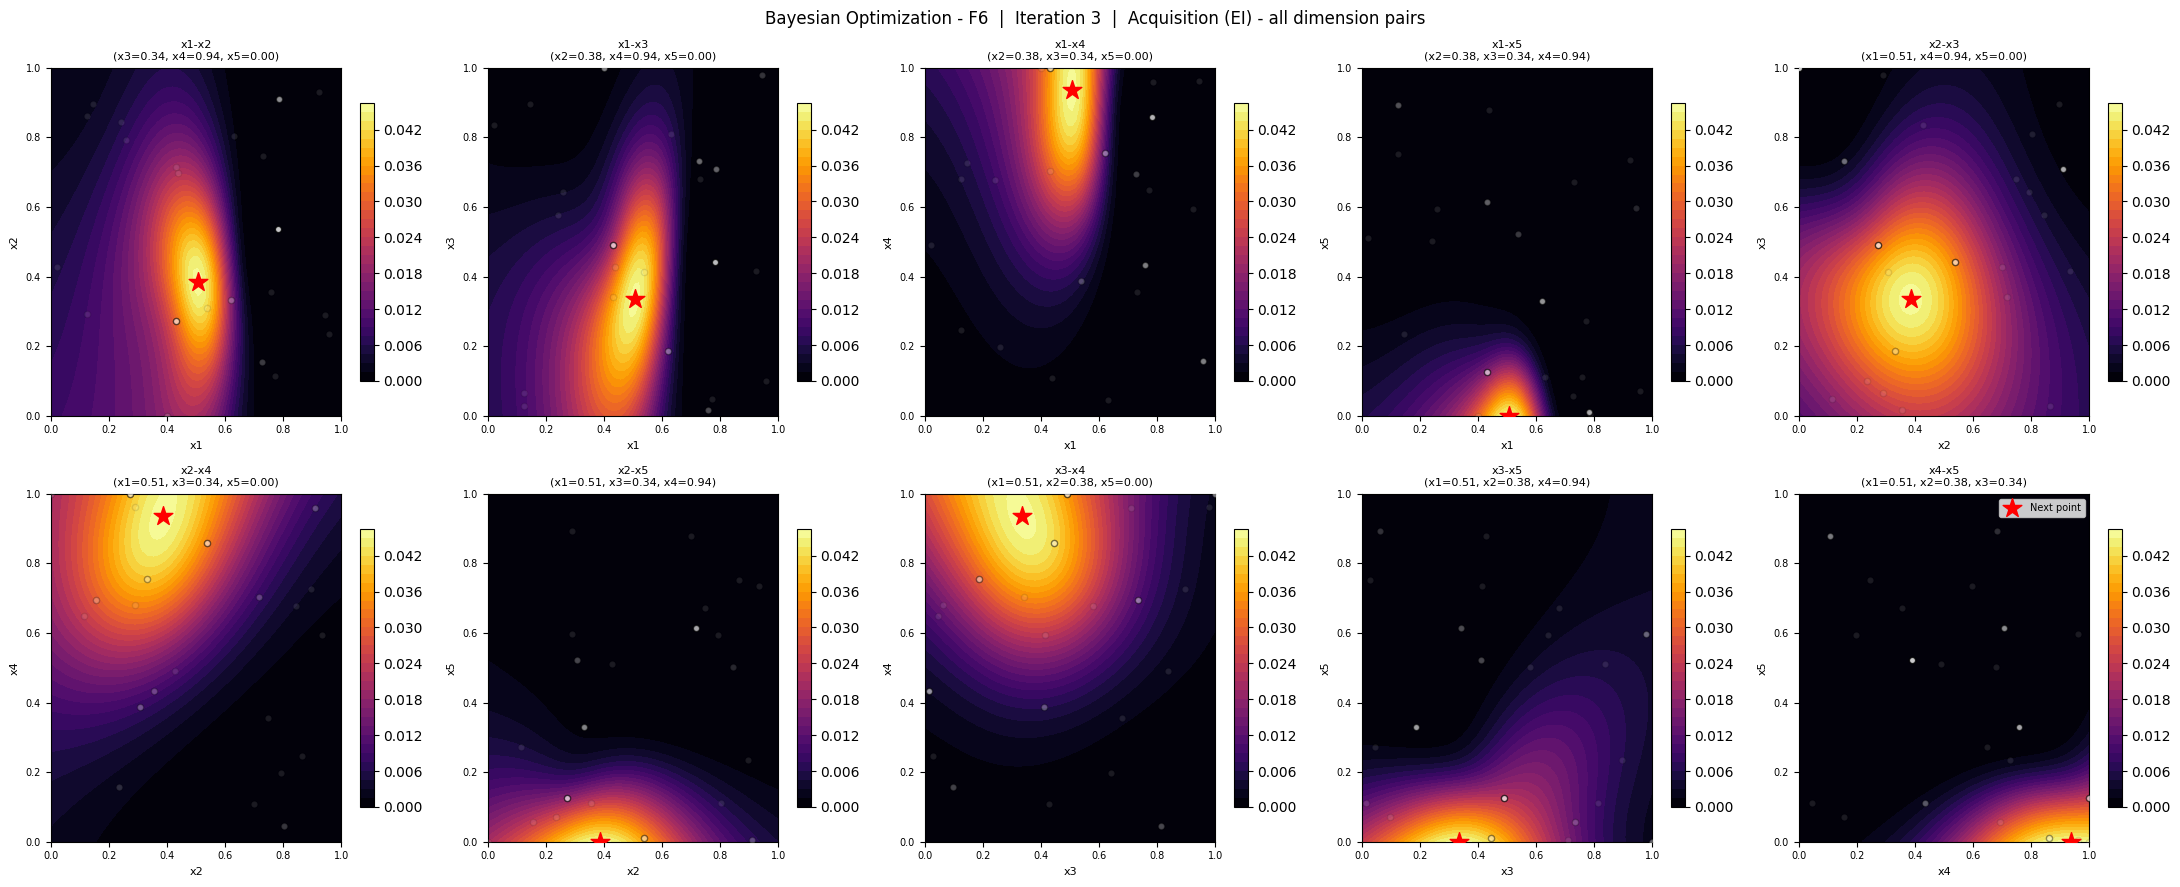

C:\Users\fakep\AppData\Local\Temp\ipykernel_22264\1562328627.py:14: UserWarning: The balance properties of Sobol' points require n to be a power of 2.
  X_cand  = sampler.random(n_sobol)



  Iteration   4  |  xi = 0.06141  |  acq = EI
  Current best y  : -0.475132  (maximising toward zero)
  ✅ Suggested x CAPSTONE       : 0.234141-0.284889-0.727654-1.0-0.0
  Suggested x     : [0.234141, 0.284889, 0.727654, 1.0, 0.0]
  Acq. score      : 0.021411


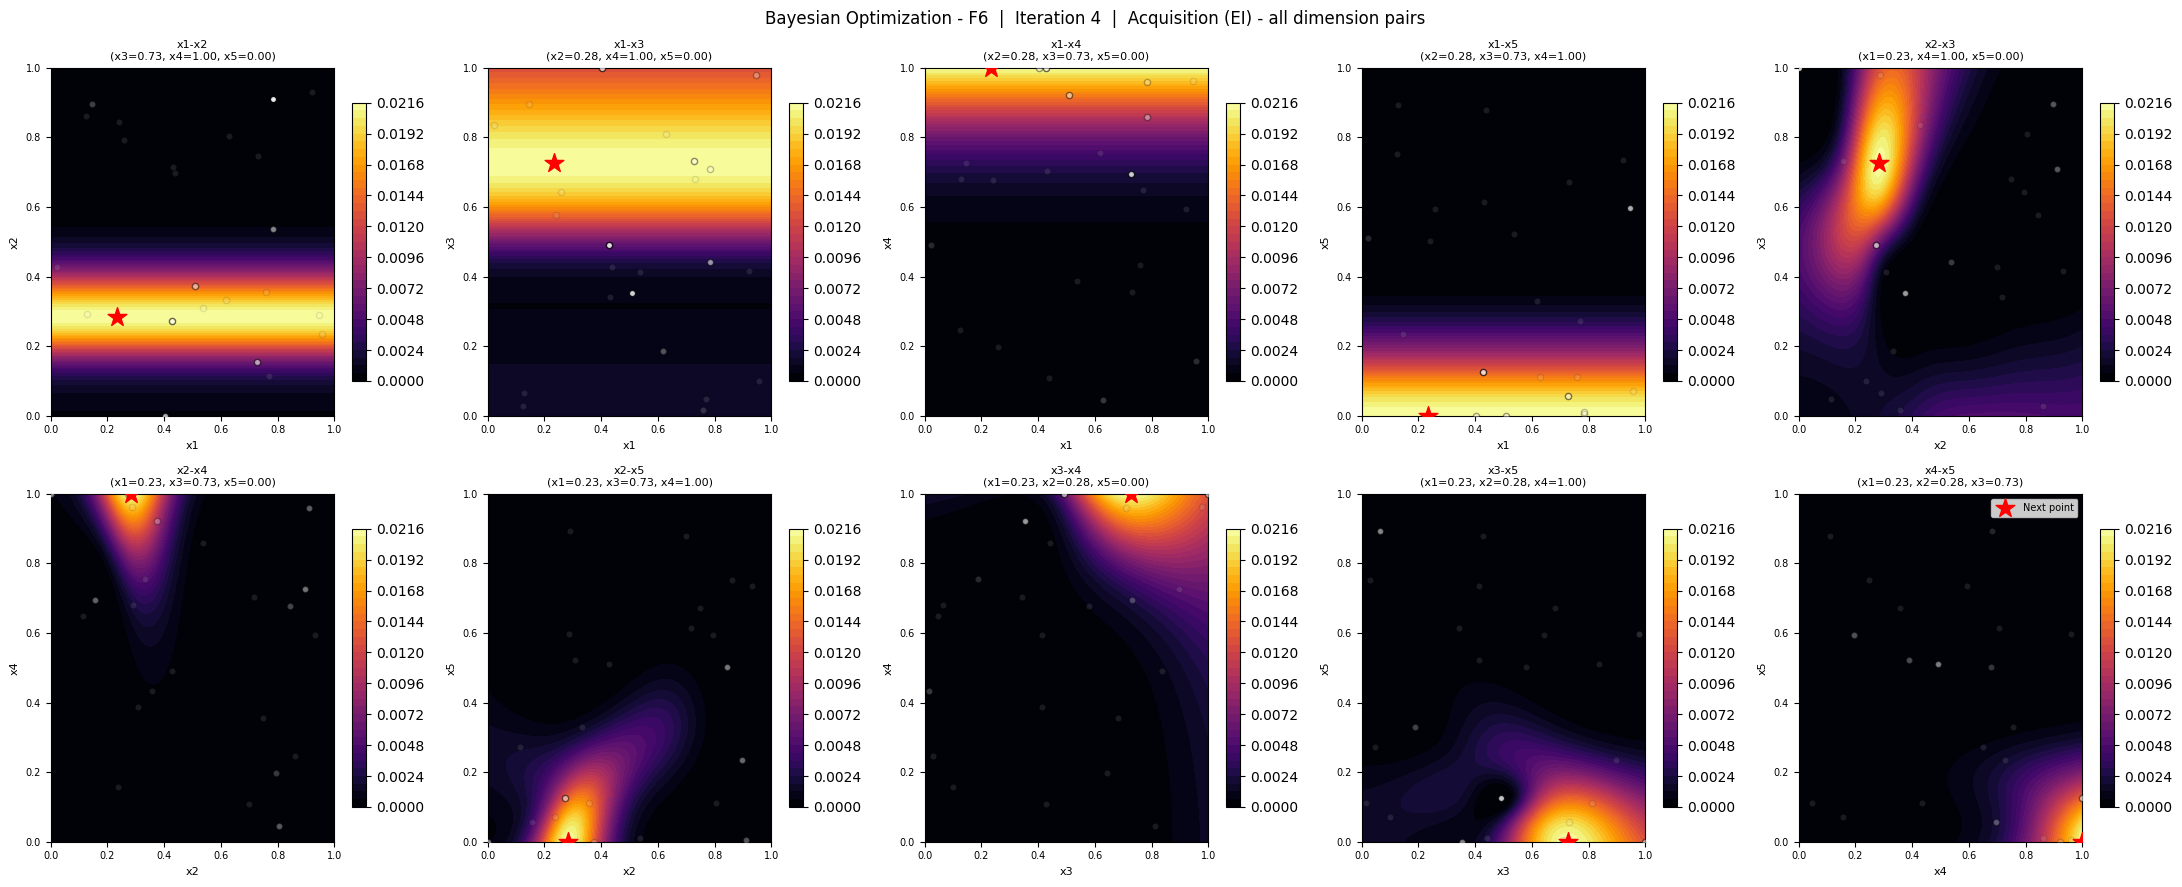

C:\Users\fakep\AppData\Local\Temp\ipykernel_22264\1562328627.py:14: UserWarning: The balance properties of Sobol' points require n to be a power of 2.
  X_cand  = sampler.random(n_sobol)



  Iteration   5  |  xi = 0.05220  |  acq = EI
  Current best y  : -0.475132  (maximising toward zero)
  ✅ Suggested x CAPSTONE       : 0.009281-0.452951-0.373196-1.0-0.277018
  Suggested x     : [0.009281, 0.452951, 0.373196, 1.0, 0.277018]
  Acq. score      : 0.033049


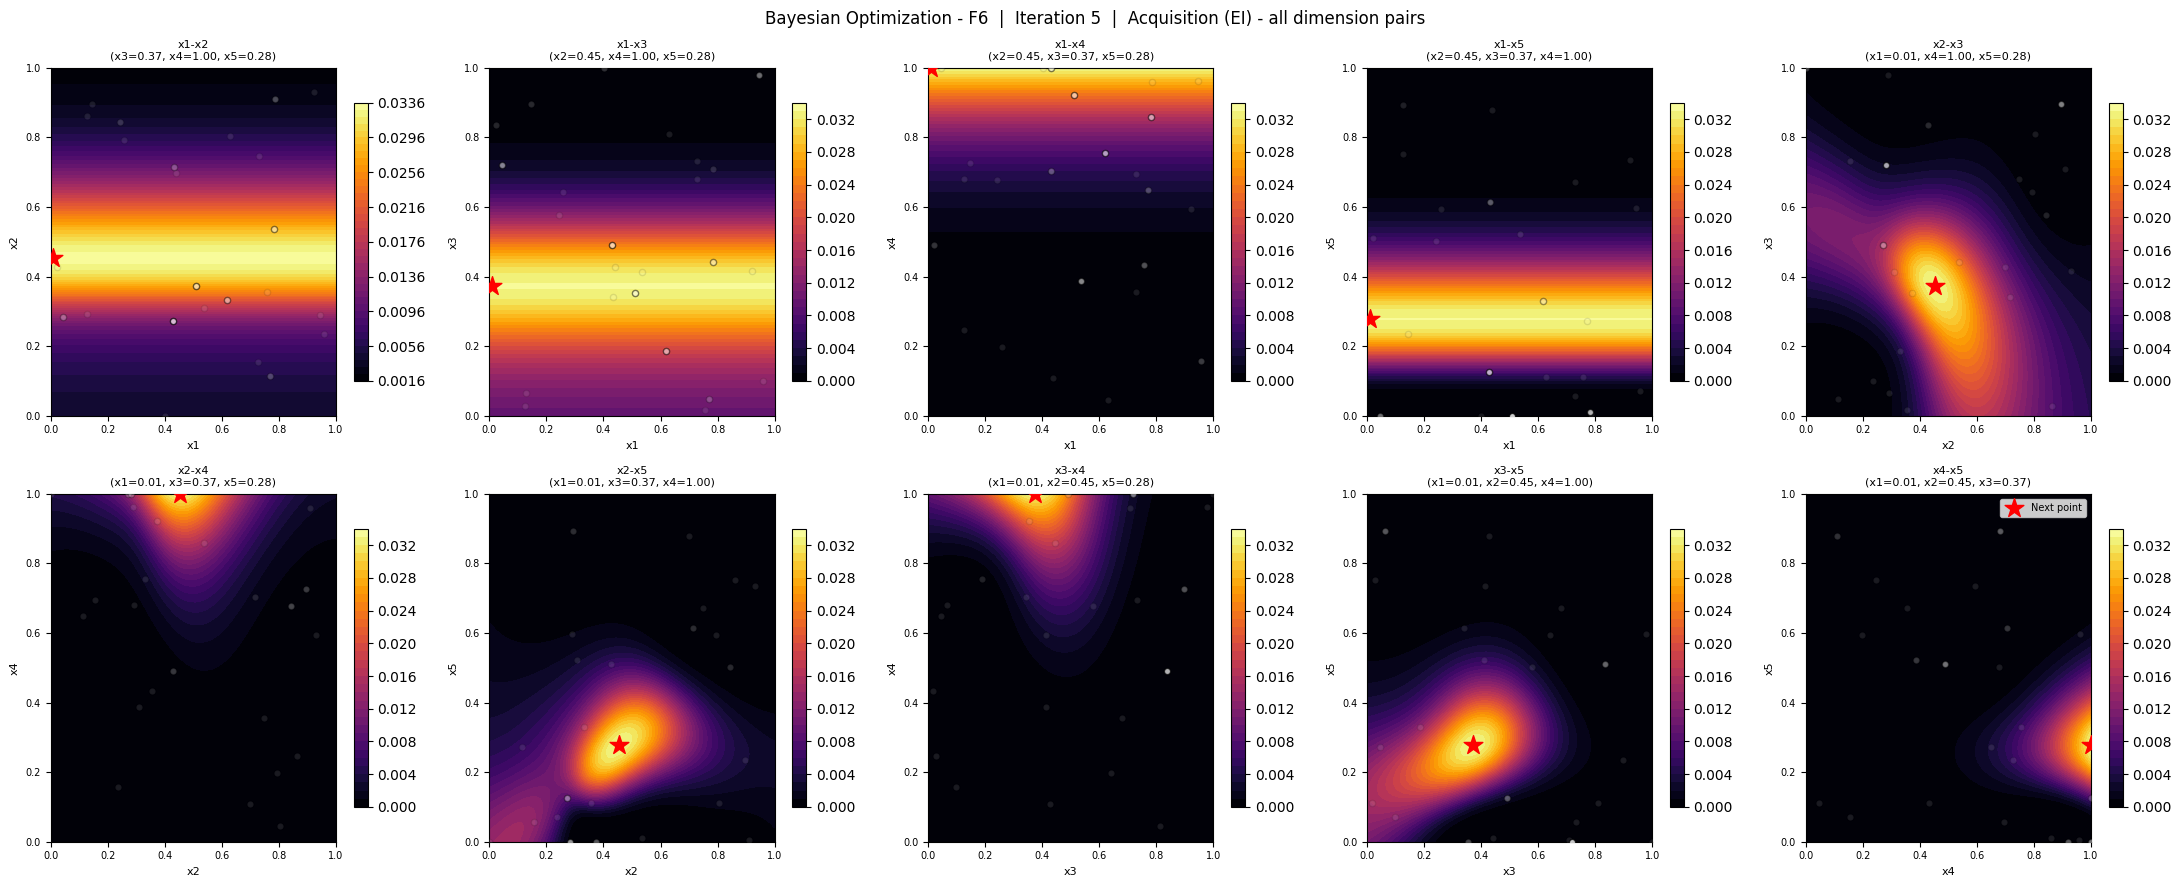

C:\Users\fakep\AppData\Local\Temp\ipykernel_22264\1562328627.py:14: UserWarning: The balance properties of Sobol' points require n to be a power of 2.
  X_cand  = sampler.random(n_sobol)



  Iteration   6  |  xi = 0.04437  |  acq = EI
  Current best y  : -0.475132  (maximising toward zero)
  ✅ Suggested x CAPSTONE       : 0.073475-0.55528-0.146474-1.0-0.224413
  Suggested x     : [0.073475, 0.55528, 0.146474, 1.0, 0.224413]
  Acq. score      : 0.022716


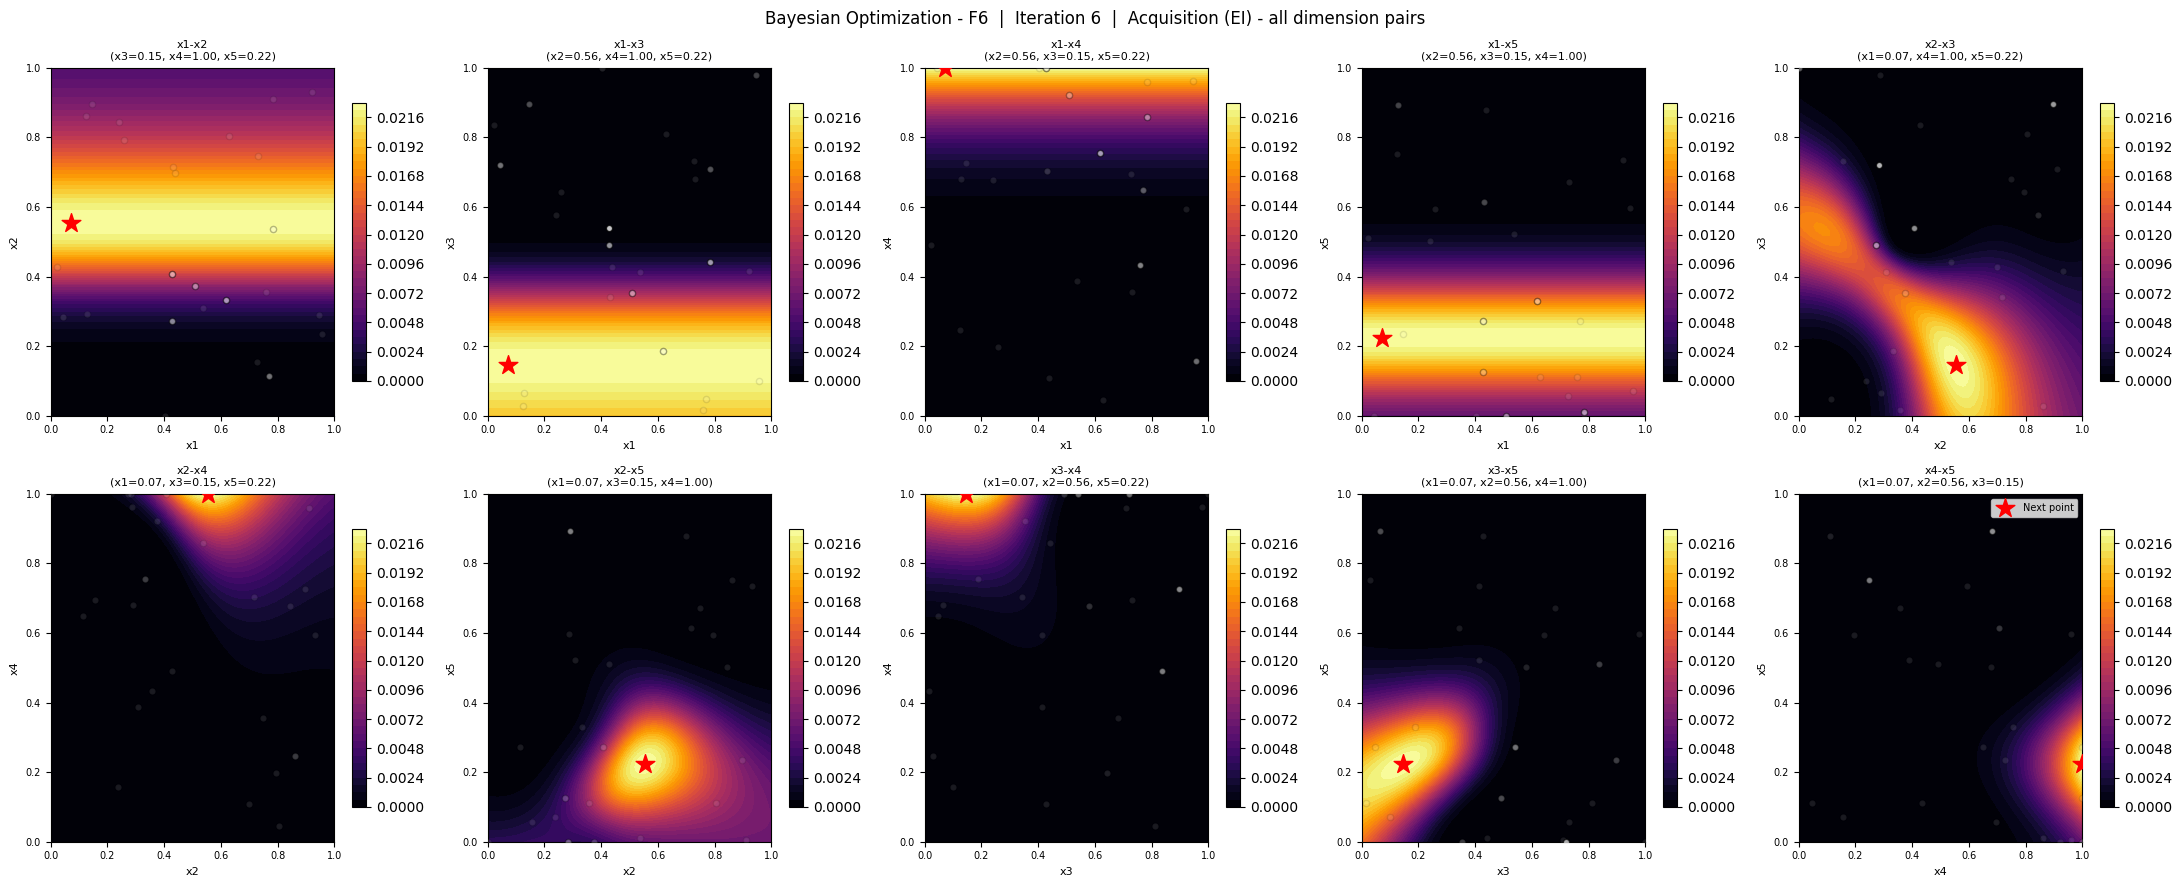

C:\Users\fakep\AppData\Local\Temp\ipykernel_22264\1562328627.py:14: UserWarning: The balance properties of Sobol' points require n to be a power of 2.
  X_cand  = sampler.random(n_sobol)



  Iteration   7  |  xi = 0.03771  |  acq = EI
  Current best y  : -0.475132  (maximising toward zero)
  ✅ Suggested x CAPSTONE       : 0.457375-0.42237-0.642123-1.0-0.0
  Suggested x     : [0.457375, 0.42237, 0.642123, 1.0, 0.0]
  Acq. score      : 0.036249


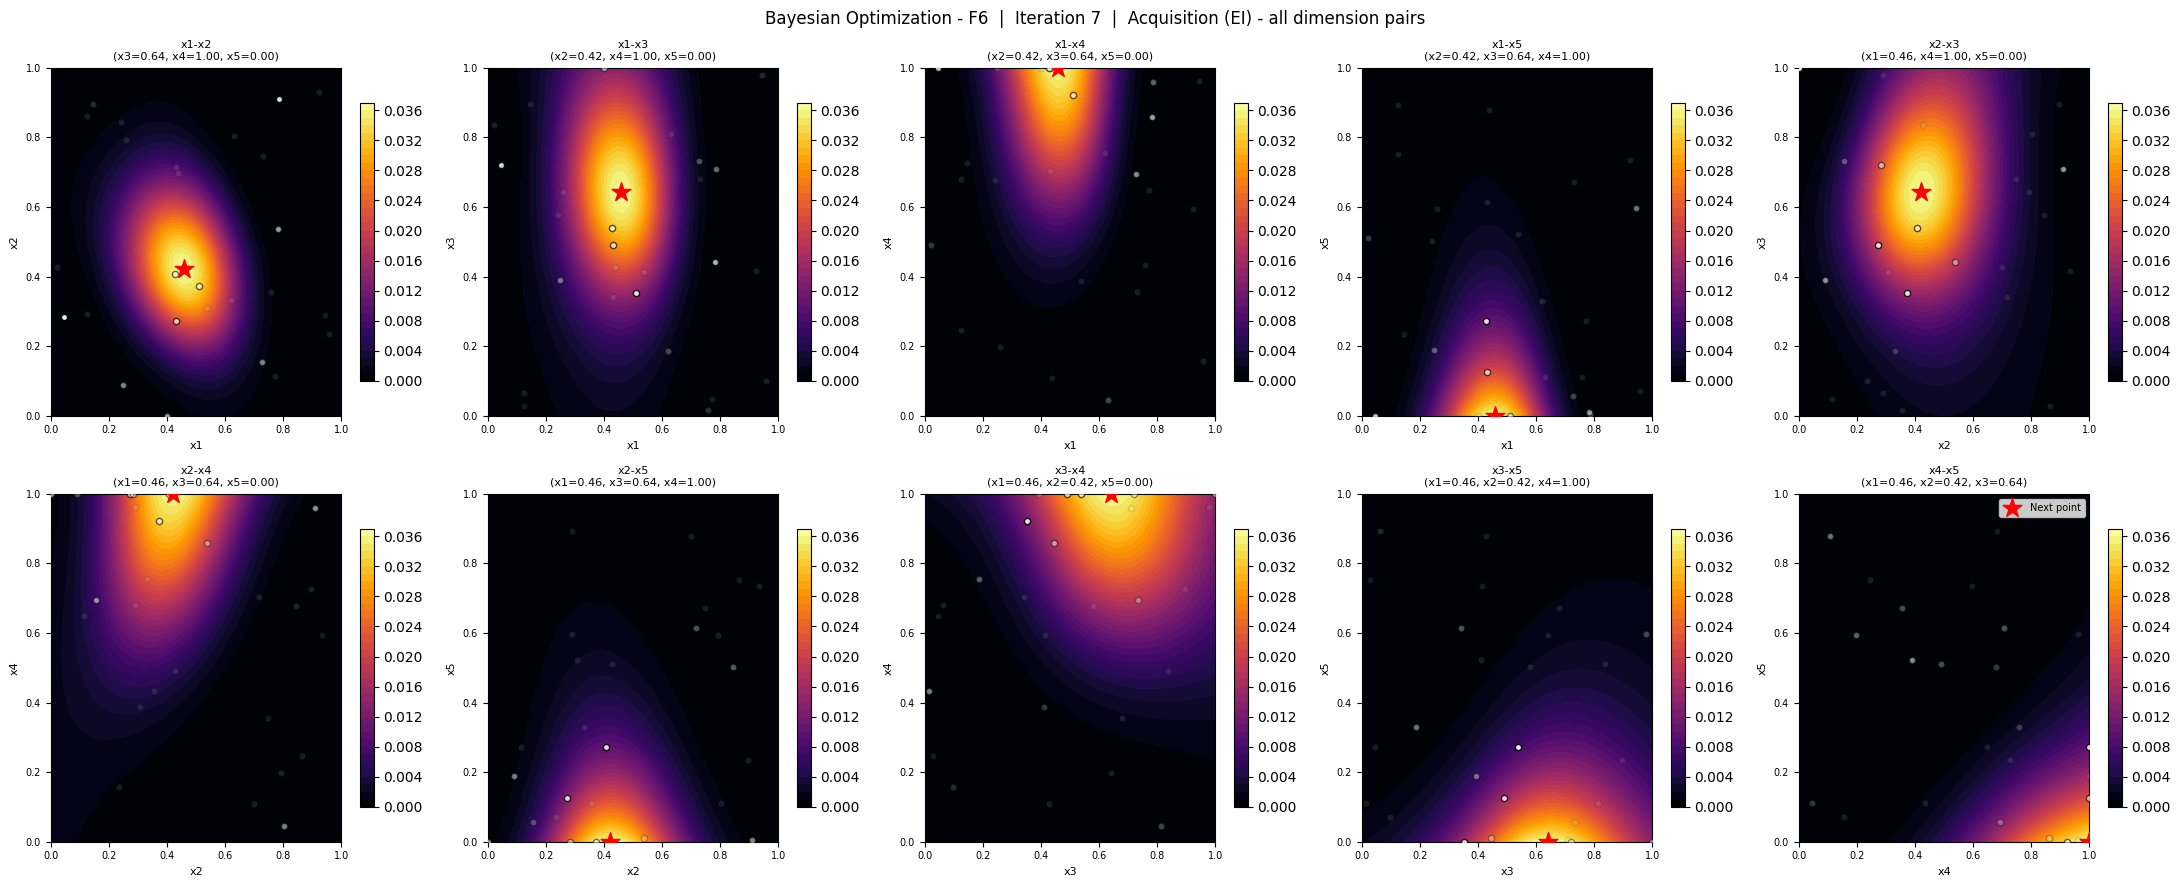

C:\Users\fakep\AppData\Local\Temp\ipykernel_22264\1562328627.py:14: UserWarning: The balance properties of Sobol' points require n to be a power of 2.
  X_cand  = sampler.random(n_sobol)



  Iteration   8  |  xi = 0.03206  |  acq = EI
  Current best y  : -0.475132  (maximising toward zero)
  ✅ Suggested x CAPSTONE       : 0.44532-0.433503-0.677728-0.983058-0.0
  Suggested x     : [0.44532, 0.433503, 0.677728, 0.983058, 0.0]
  Acq. score      : 0.038820


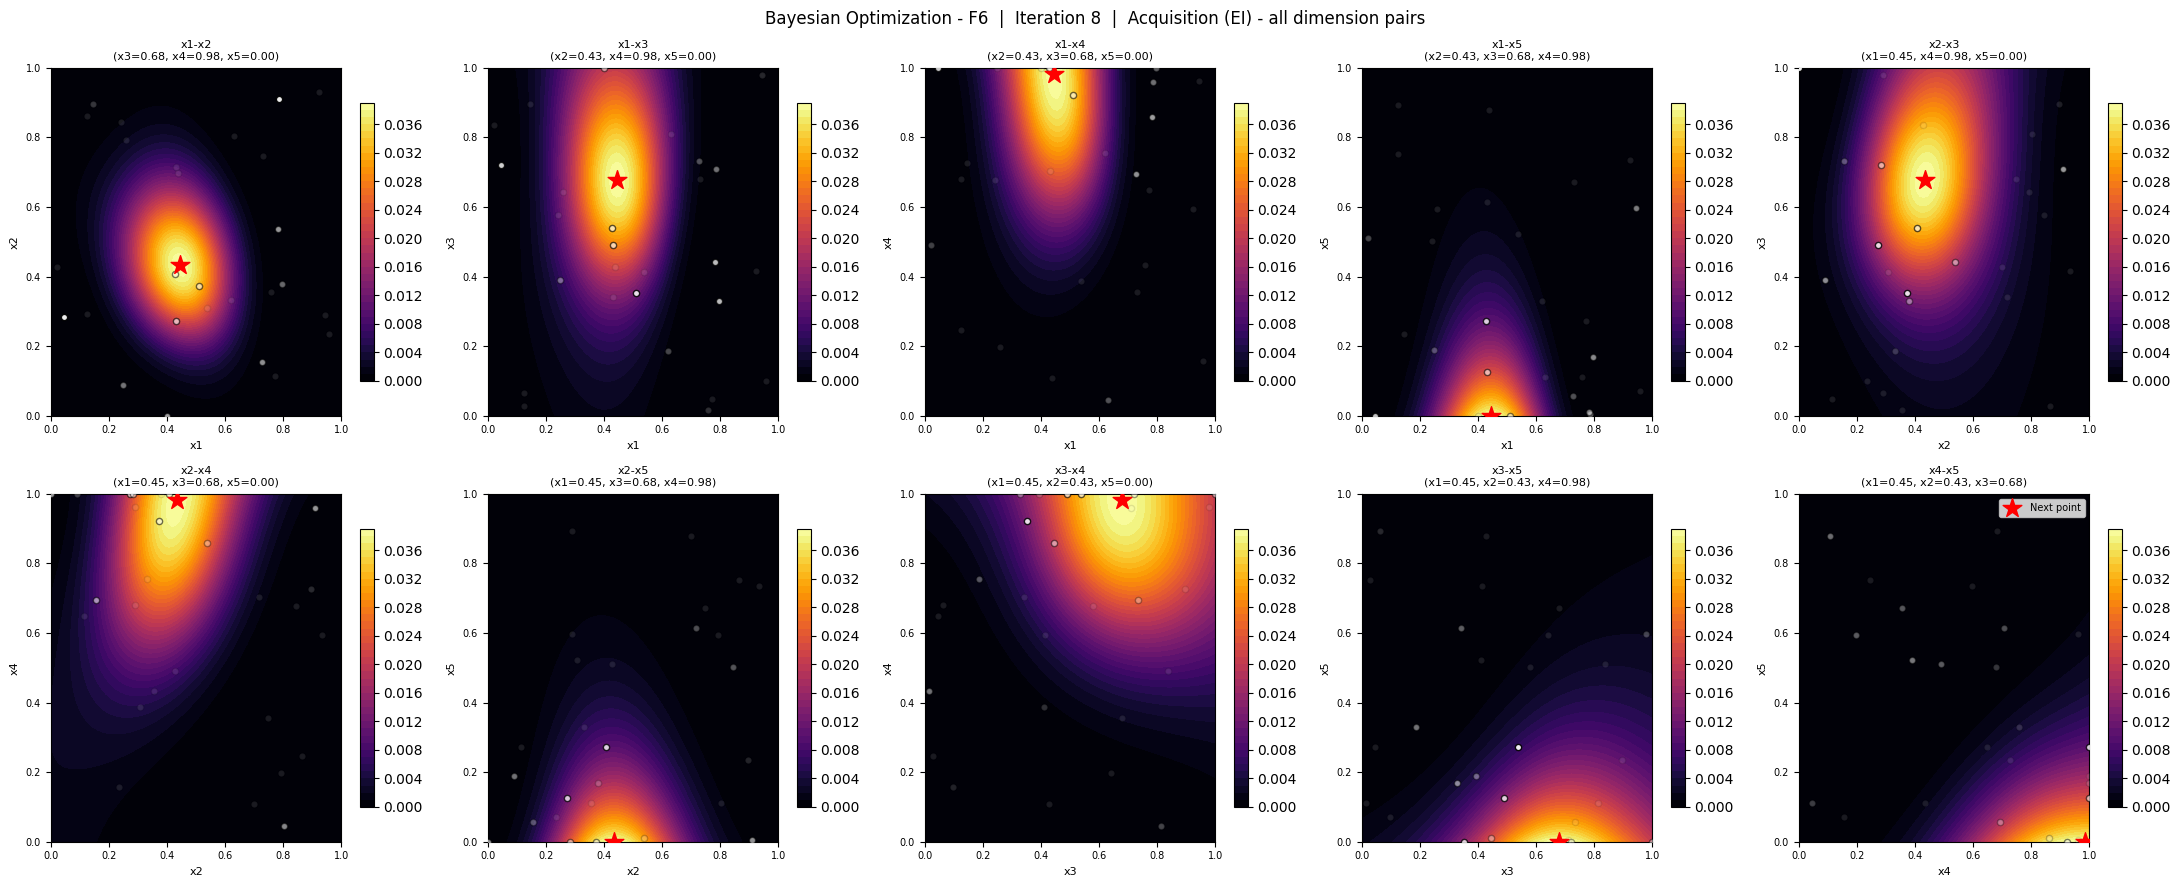

C:\Users\fakep\AppData\Local\Temp\ipykernel_22264\1562328627.py:14: UserWarning: The balance properties of Sobol' points require n to be a power of 2.
  X_cand  = sampler.random(n_sobol)



  Iteration   9  |  xi = 0.02725  |  acq = EI
  Current best y  : -0.475132  (maximising toward zero)
  ✅ Suggested x CAPSTONE       : 0.463795-0.388178-0.615531-0.900788-0.0
  Suggested x     : [0.463795, 0.388178, 0.615531, 0.900788, 0.0]
  Acq. score      : 0.023517


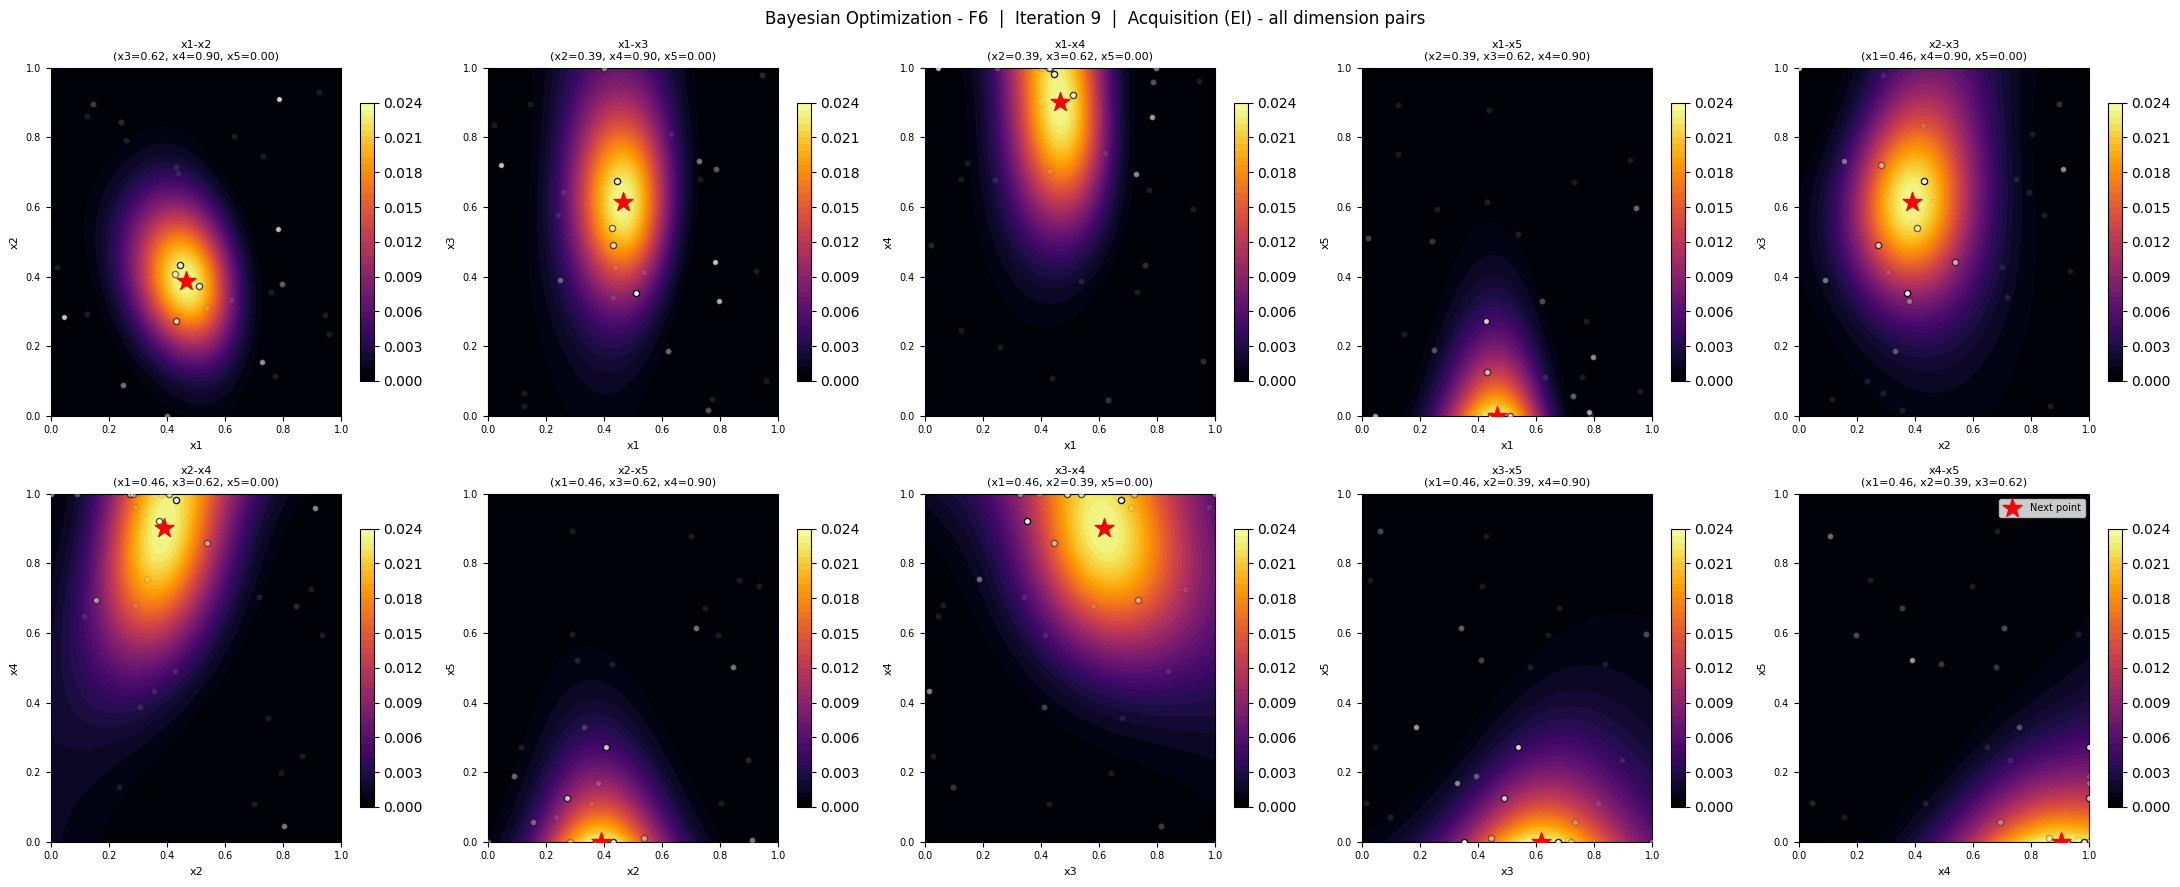

C:\Users\fakep\AppData\Local\Temp\ipykernel_22264\1562328627.py:14: UserWarning: The balance properties of Sobol' points require n to be a power of 2.
  X_cand  = sampler.random(n_sobol)



  Iteration  10  |  xi = 0.02316  |  acq = EI
  Current best y  : -0.402833  (maximising toward zero)
  ✅ Suggested x CAPSTONE       : 0.457478-0.378088-0.654848-0.812513-0.0
  Suggested x     : [0.457478, 0.378088, 0.654848, 0.812513, 0.0]
  Acq. score      : 0.014005


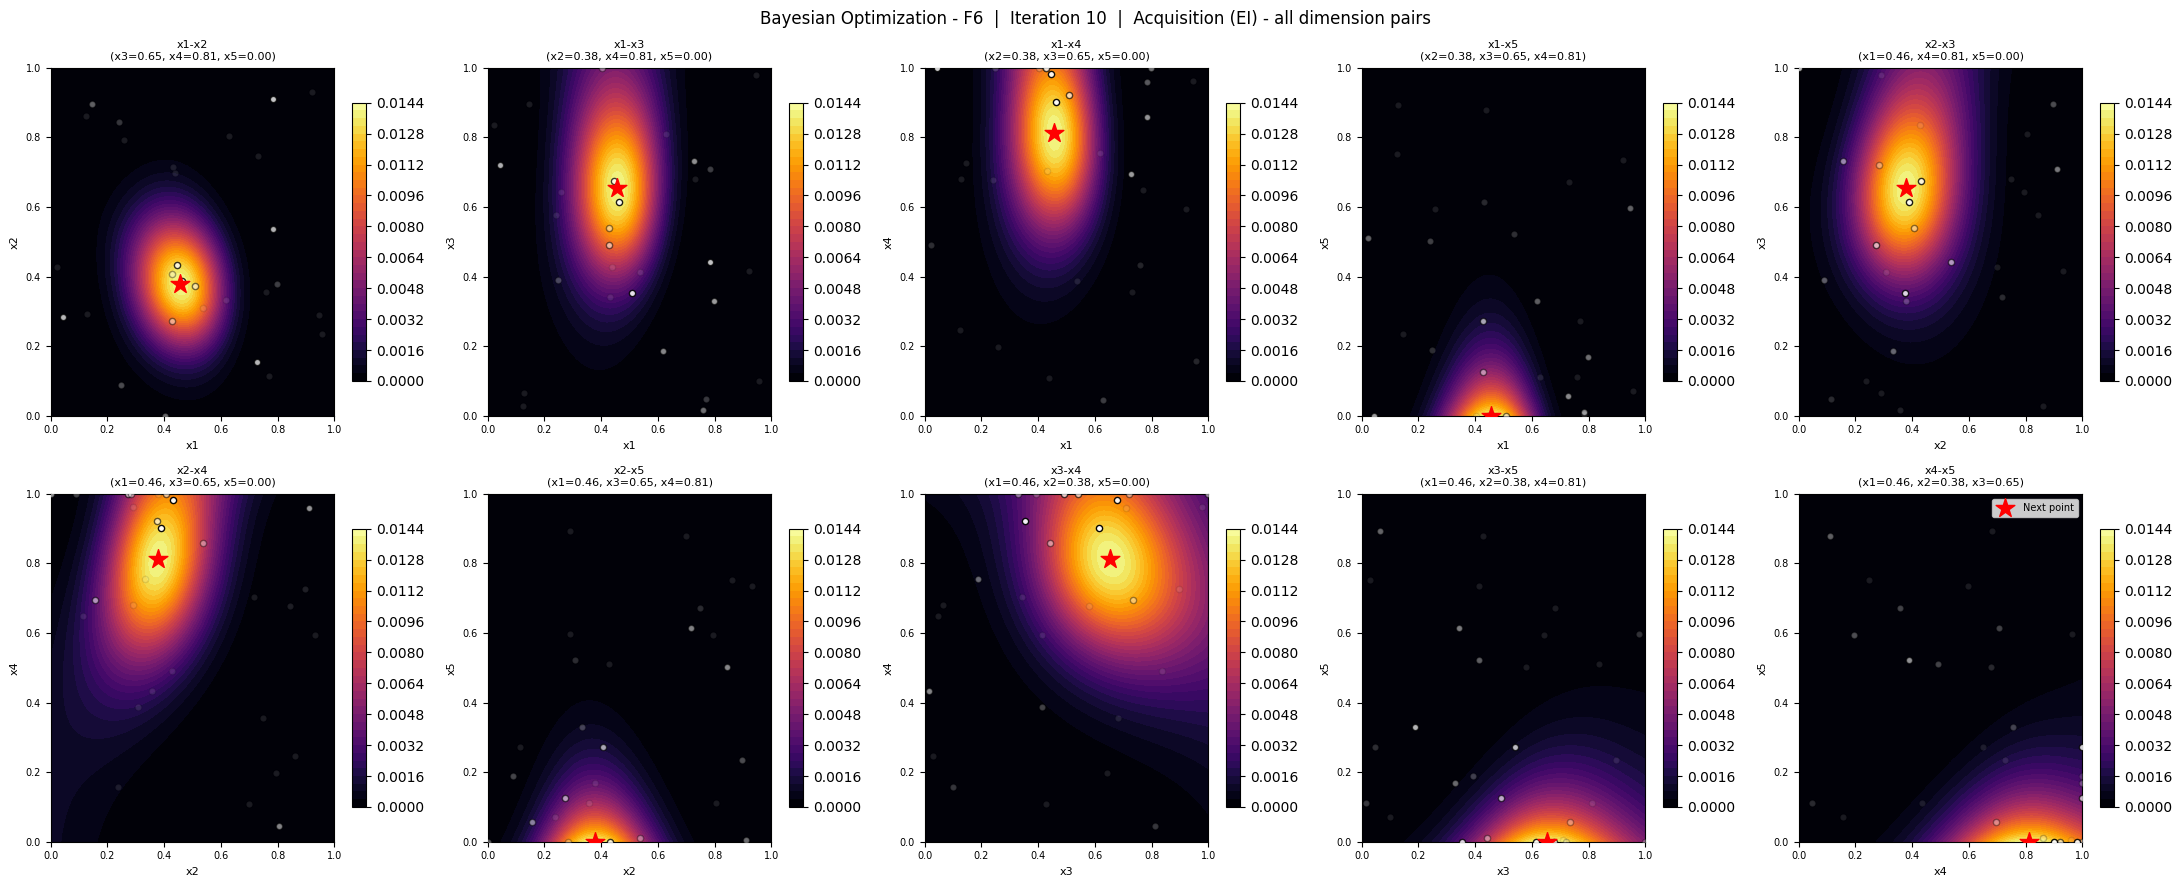

In [7]:
# ── Past Week Data ─────────────────────────────────────────────────────────────
X_new_Data = np.array([]).reshape(0, 5)
y_new_Data = np.array([])

# Week1 addition
X_new_Data = np.vstack([X_new_Data, [0.429335, 0.272387, 0.490539, 0.999999, 0.126862]])
y_new_Data = np.hstack([y_new_Data, -0.47513200244903914])

# Week2 addition
X_new_Data = np.vstack([X_new_Data, [0.401691, 0.000000, 0.999999, 0.999999, 0.000000]])
y_new_Data = np.hstack([y_new_Data, -1.0280251832256417])

# Week3 addition
X_new_Data = np.vstack([X_new_Data, [0.510055, 0.373765, 0.352908, 0.921368, 0.000000]])
y_new_Data = np.hstack([y_new_Data, -0.6724590841229099])

# Week4 addition
X_new_Data = np.vstack([X_new_Data, [0.044728, 0.282461, 0.719800, 1.000000, 0.000000]])
y_new_Data = np.hstack([y_new_Data, -0.8759469228318271])

# Week5 addition
X_new_Data = np.vstack([X_new_Data, [0.428100, 0.406934, 0.538880, 1.000000, 0.272596]])
y_new_Data = np.hstack([y_new_Data, -0.5968020780151513])

# Week6 addition
X_new_Data = np.vstack([X_new_Data, [0.247383, 0.089328, 0.391609, 1.000000, 0.189817]])
y_new_Data = np.hstack([y_new_Data, -0.9901554713734176])

# Week7 addition
X_new_Data = np.vstack([X_new_Data, [0.796896, 0.379193, 0.328733, 1.000000, 0.169381]])
y_new_Data = np.hstack([y_new_Data, -1.0840108997195066])

# Week8 addition
X_new_Data = np.vstack([X_new_Data, [0.445676, 0.432561, 0.676110, 0.981786, 0.000000]])
y_new_Data = np.hstack([y_new_Data, -0.5540734551623457])

# Week9 addition
X_new_Data = np.vstack([X_new_Data, [0.463795, 0.388178, 0.615531, 0.900788, 0.000000]])
y_new_Data = np.hstack([y_new_Data, -0.4028331935346454])

# ── Configuration ─────────────────────────────────────────────────────────────
N_ITER   = len(y_new_Data)+1       # number of BO steps to run
ACQ      = "ei"    # "ei" or "ucb"
XI_INIT  = 0.1     # matches original F6 xi
XI_DECAY = 0.85
KAPPA    = 2.576   # only used if ACQ = "ucb"

# ── History (seeded with initial observations) ────────────────────────────────
X_obs        = X.copy()
y_obs        = y.copy()
history_best = [y_obs.max()]

for iteration in range(N_ITER):

    # 1. Fit GP on raw outputs (no transform needed for F6)
    gp    = build_gp(n_dim)
    gp.fit(X_obs, y_obs)
    y_max = y_obs.max()

    # 2. Compute adaptive xi for this iteration
    xi = adaptive_xi(iteration, xi_init=XI_INIT, decay=XI_DECAY)

    # 3. Define acquisition callable for the plot helper
    if ACQ == "ucb":
        acq_fn    = lambda X_c: upper_confidence_bound(X_c, gp, kappa=KAPPA)
        acq_label = "UCB"
    else:
        acq_fn    = lambda X_c: expected_improvement(X_c, gp, y_max, xi=xi)
        acq_label = "EI"

    # 4. Suggest next point
    x_next, score = suggest_next_point(
        gp, y_max, n_dim,
        xi=xi, acq=ACQ, kappa=KAPPA,
        seed=SEED + iteration
    )

    # 5. Print summary
    print("\n" + "="*62)
    print(f"  Iteration {iteration + 1:>3d}  |  xi = {xi:.5f}  |  acq = {acq_label}")
    print(f"  Current best y  : {y_max:.6f}  (maximising toward zero)")
    print(f"  ✅ Suggested x CAPSTONE       : {np.round(x_next[0], 6)}-{np.round(x_next[1], 6)}-{np.round(x_next[2], 6)}-{np.round(x_next[3], 6)}-{np.round(x_next[4], 6)}")
    print(f"  Suggested x     : {np.round(x_next, 6).tolist()}")
    print(f"  Acq. score      : {score:.6f}")
    print("="*62)

    # 6. Visualise acquisition slices — all 10 dimension pairs
    plot_slices_5d(gp, X_obs, x_next, acq_fn,
                   iteration=iteration + 1, acq_label=acq_label)

    # ── PAST WEEKS DATA ──────────────────────────────────────────────
    if iteration < len(y_new_Data):
        y_new  = y_new_Data[iteration]
        X_obs  = np.vstack([X_obs, X_new_Data[iteration]])
        y_obs  = np.append(y_obs, y_new)
        history_best.append(y_obs.max())
    # ─────────────────────────────────────────────────────────────────────────

## 8. SVM classifier on observed data

In [8]:
# Threshold: top 25% of log-transformed observations = "high"
threshold = np.percentile(y_obs, 75)
labels = (y_obs >= threshold).astype(int)  # 1 = high, 0 = low

print(f"Threshold (75th pct, log-space): {threshold:.4f}")
print(f"High-performing points : {labels.sum()} / {len(labels)}")

# Scale inputs (SVM is sensitive to scale)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_obs)

# Soft-margin SVM with RBF kernel (handles non-linear boundaries)
# C controls margin softness: lower C = wider margin, more generalisation
# gamma='scale' = 1/(n_features * X.var()), a robust default
svm = SVC(kernel='rbf', C=1.0, gamma='scale', probability=True)
svm.fit(X_scaled, labels)

print(f"\nSVM kernel  : {svm.kernel}")
print(f"Support vectors : {svm.n_support_} (class 0 / class 1)")

Threshold (75th pct, log-space): -0.8759
High-performing points : 8 / 29

SVM kernel  : rbf
Support vectors : [11  7] (class 0 / class 1)


## 9. Visualise the SVM decision boundary alongside GP

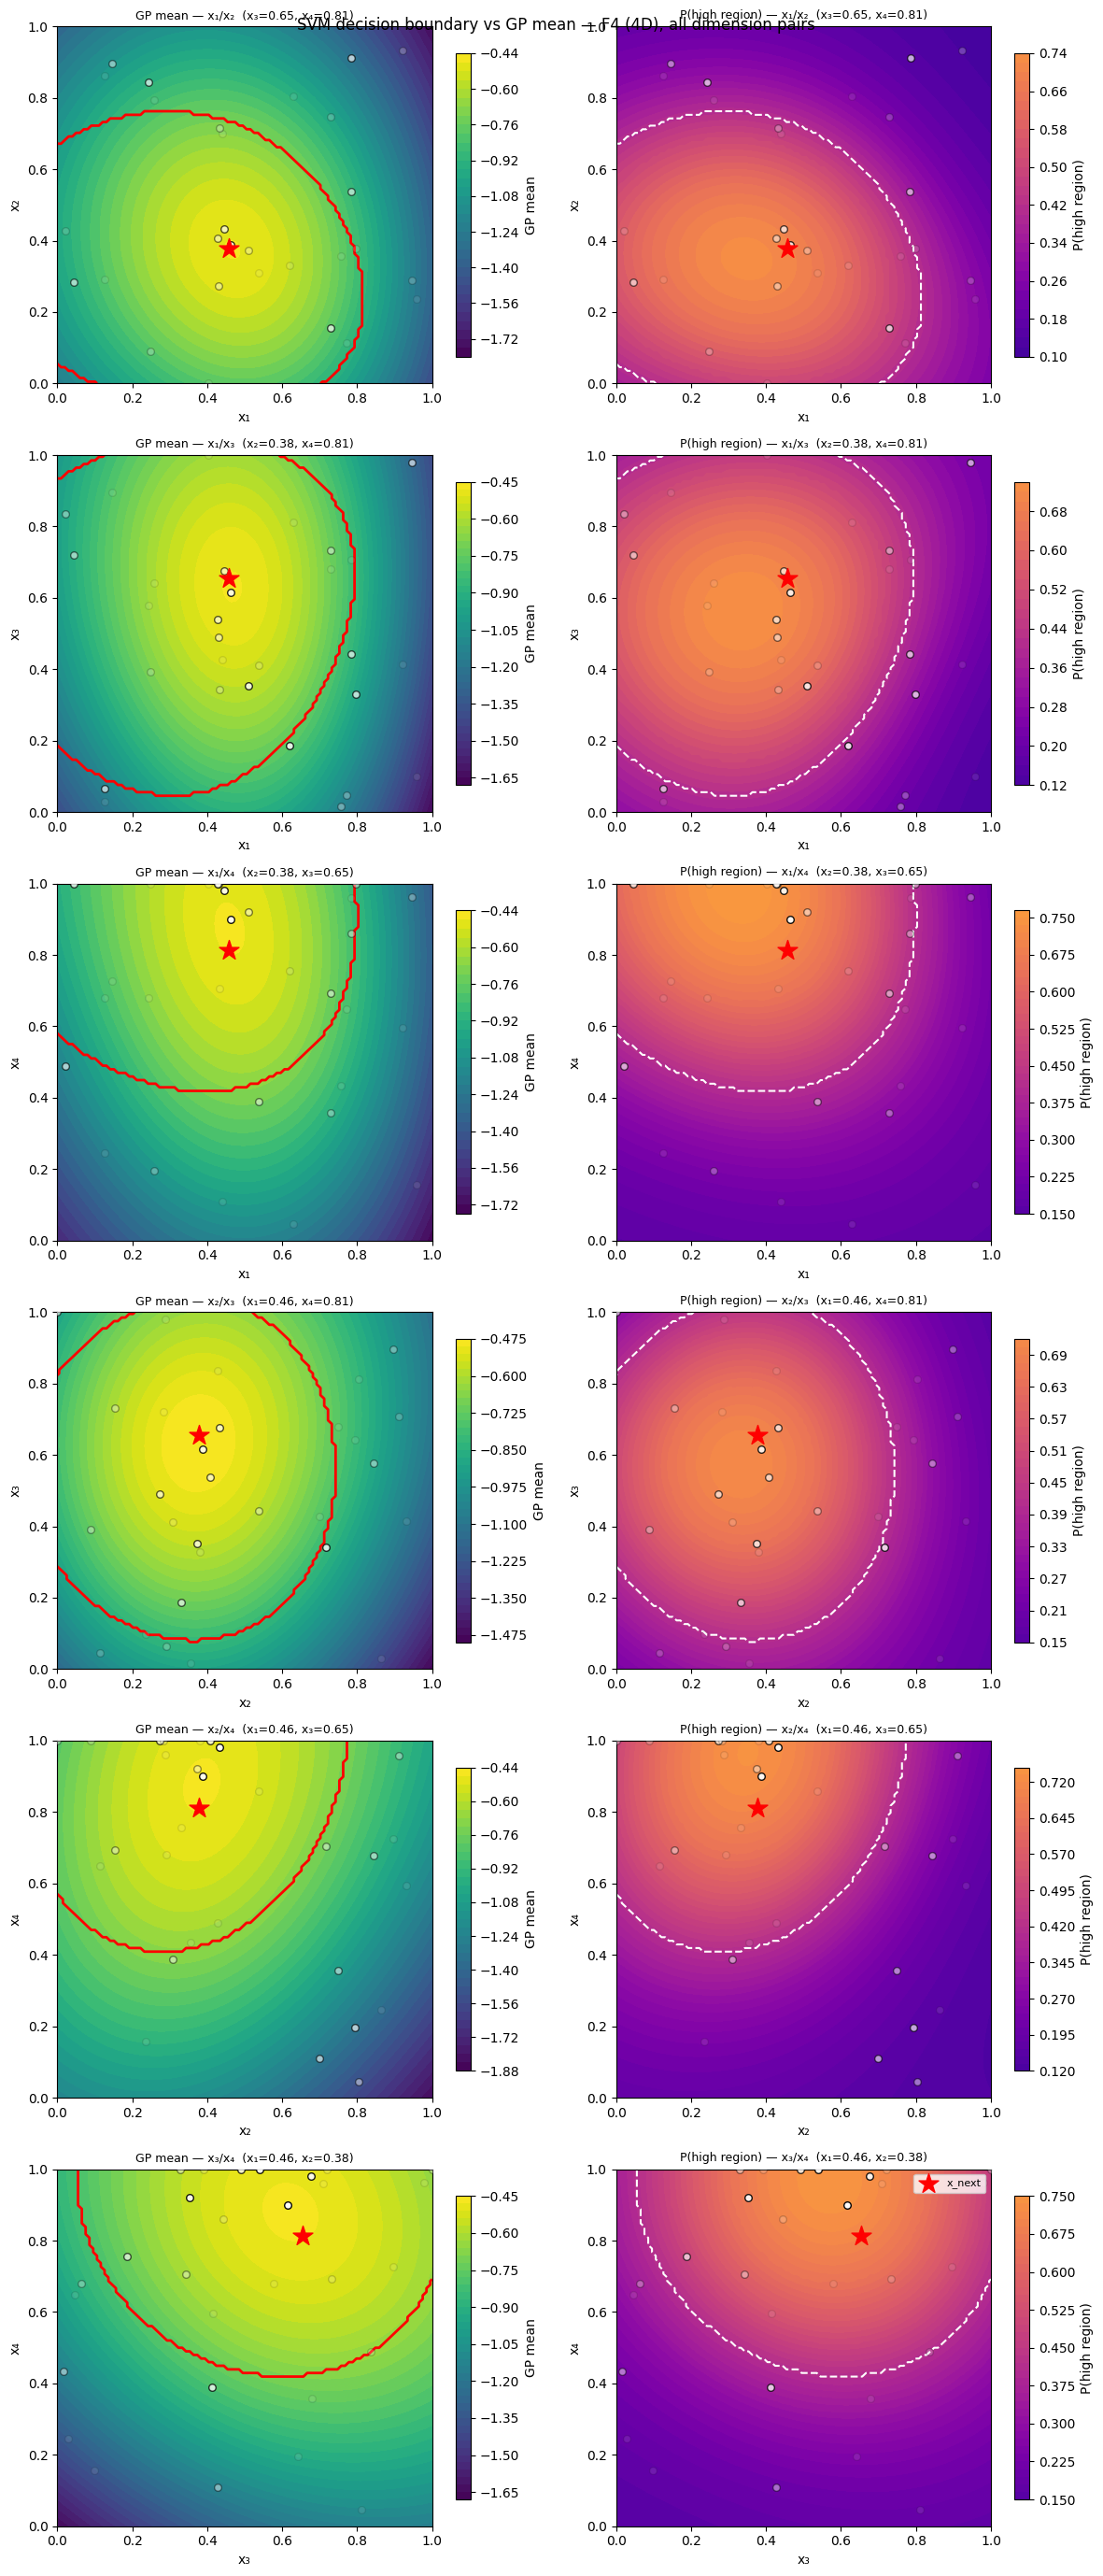

In [9]:
# ── Plot: SVM probability slices — all 6 dimension pairs (4D) ────────────────
from itertools import combinations

resolution = 100
grid_1d    = np.linspace(0, 1, resolution)
G1, G2     = np.meshgrid(grid_1d, grid_1d)
flat1, flat2 = G1.ravel(), G2.ravel()

dim_labels = ["x₁", "x₂", "x₃", "x₄"]
dim_pairs  = list(combinations(range(4), 2))   # 6 pairs

fig, axes = plt.subplots(6, 2, figsize=(12, 28))  # 6 rows × 2 cols
fig.suptitle("SVM decision boundary vs GP mean — F4 (4D), all dimension pairs", fontsize=12)

for row, (d0, d1) in enumerate(dim_pairs):
    fixed_dims = [d for d in range(4) if d not in (d0, d1)]

    # Build 4-column grid: sweep d0 & d1, fix the other two at x_next values
    X_grid = np.tile(x_next, (resolution * resolution, 1))
    X_grid[:, d0] = flat1
    X_grid[:, d1] = flat2

    # GP mean
    mu_slice, _ = gp.predict(X_grid, return_std=True)
    mu_slice     = mu_slice.reshape(resolution, resolution)

    # SVM predictions
    X_grid_scaled  = scaler.transform(X_grid)
    svm_prob_slice = svm.predict_proba(X_grid_scaled)[:, 1].reshape(resolution, resolution)
    svm_pred_slice = svm.predict(X_grid_scaled).reshape(resolution, resolution)

    # Opacity: average proximity across both fixed dims
    dist   = np.mean([np.abs(X_obs[:, fd] - x_next[fd]) for fd in fixed_dims], axis=0)
    alphas = np.clip(1.0 - dist / 0.3, 0.1, 1.0)
    fix_str = ", ".join(f"{dim_labels[fd]}={x_next[fd]:.2f}" for fd in fixed_dims)

    # Left column: GP mean + SVM boundary
    ax = axes[row, 0]
    im = ax.contourf(G1, G2, mu_slice, levels=40, cmap="viridis")
    fig.colorbar(im, ax=ax, shrink=0.85, label="GP mean")
    ax.contour(G1, G2, svm_pred_slice, levels=[0.5], colors="red", linewidths=2)
    for xi_obs, yi_obs, a in zip(X_obs[:, d0], X_obs[:, d1], alphas):
        ax.scatter(xi_obs, yi_obs, c="white", edgecolors="black",
                   s=30, alpha=float(a), zorder=5)
    ax.scatter(x_next[d0], x_next[d1], c="red", marker="*", s=250, zorder=6)
    ax.set_title(f"GP mean — {dim_labels[d0]}/{dim_labels[d1]}  ({fix_str})", fontsize=9)
    ax.set_xlabel(dim_labels[d0]); ax.set_ylabel(dim_labels[d1])

    # Right column: SVM P(high)
    ax = axes[row, 1]
    im2 = ax.contourf(G1, G2, svm_prob_slice, levels=40, cmap="plasma", vmin=0, vmax=1)
    fig.colorbar(im2, ax=ax, shrink=0.85, label="P(high region)")
    ax.contour(G1, G2, svm_pred_slice, levels=[0.5], colors="white",
               linewidths=1.5, linestyles="--")
    for xi_obs, yi_obs, a in zip(X_obs[:, d0], X_obs[:, d1], alphas):
        ax.scatter(xi_obs, yi_obs, c="white", edgecolors="black",
                   s=30, alpha=float(a), zorder=5)
    ax.scatter(x_next[d0], x_next[d1], c="red", marker="*", s=250,
               zorder=6, label="x_next")
    ax.set_title(f"P(high region) — {dim_labels[d0]}/{dim_labels[d1]}  ({fix_str})", fontsize=9)
    ax.set_xlabel(dim_labels[d0]); ax.set_ylabel(dim_labels[d1])

axes[-1, 1].legend(loc="upper right", fontsize=8)
plt.tight_layout()
plt.savefig("svm_boundary_f4.png", dpi=150)
plt.show()

## 10. SVM-constrained next point suggestion

In [10]:
# ── Constrained BO: suggest next point inside SVM "high" region ──────────────
from scipy.stats import qmc

# Generate a large Sobol candidate set
sampler = qmc.Sobol(d=n_dim, scramble=True, seed=SEED + 99)
X_cand = sampler.random(20_000)

# Keep only candidates the SVM classifies as "high"
X_cand_scaled = scaler.transform(X_cand)
svm_labels    = svm.predict(X_cand_scaled)
svm_probs     = svm.predict_proba(X_cand_scaled)[:, 1]

# Filter: inside SVM high region AND probability > 0.5
mask = (svm_labels == 1) & (svm_probs > 0.5)
X_constrained = X_cand[mask]

print(f"Candidates in high region : {mask.sum()} / {len(X_cand)} "
      f"({100*mask.mean():.1f}% of space)")

if len(X_constrained) < 10:
    # Fallback: boundary too restrictive, use full candidate set
    print("⚠️  Fewer than 10 constrained candidates — falling back to full set.")
    X_constrained = X_cand

# Score with EI inside the constrained region only
xi_constrained = adaptive_xi(N_ITER, xi_init=XI_INIT, decay=XI_DECAY)
ei_scores = expected_improvement(X_constrained, gp, y_obs.max(), xi=xi_constrained)

# Local optimisation from top-8 starts within the constrained region
starts = X_constrained[np.argsort(ei_scores)[-8:]]
bounds = [(0, 1)] * n_dim
obj    = lambda x: -expected_improvement(x, gp, y_obs.max(), xi=xi_constrained).item()

best_x_svm, best_score_svm = None, -np.inf
for x0 in starts:
    res = minimize(obj, x0=x0, bounds=bounds, method="L-BFGS-B")
    if -res.fun > best_score_svm:
        best_score_svm = -res.fun
        best_x_svm     = res.x

print(f"\n{'='*55}")
print(f"  SVM-constrained suggestion")
print(f"  Suggested x : {np.round(best_x_svm, 6).tolist()}")
print(f"  EI score    : {best_score_svm:.6f}")
print(f"  xi used     : {xi_constrained:.5f}")
print(f"  ✅ CAPSTONE format : {np.round(best_x_svm[0],6)}-{np.round(best_x_svm[1],6)}-{np.round(best_x_svm[2],6)}-{np.round(best_x_svm[3],6)}-{np.round(best_x_svm[4],6)}")
print(f"{'='*55}")

C:\Users\fakep\AppData\Local\Temp\ipykernel_22264\373409183.py:6: UserWarning: The balance properties of Sobol' points require n to be a power of 2.
  X_cand = sampler.random(20_000)


Candidates in high region : 388 / 20000 (1.9% of space)

  SVM-constrained suggestion
  Suggested x : [0.45757, 0.378217, 0.654116, 0.813972, 0.0]
  EI score    : 0.014735
  xi used     : 0.01969
  ✅ CAPSTONE format : 0.45757-0.378217-0.654116-0.813972-0.0


## 11. Neural Network Surrogate (MC Dropout)

We use a **PyTorch MLP with Monte Carlo Dropout** as a third surrogate. Unlike the GP (which has a closed-form posterior) or the SVM (which only classifies regions), the NN learns a direct regression mapping from input to output.

**Why MC Dropout for uncertainty?**
Dropout randomly zeroes neurons during training to prevent co-adaptation. At inference time, keeping dropout *active* and running multiple forward passes produces a distribution of predictions — the mean is the surrogate's prediction and the standard deviation is its uncertainty estimate (Gal & Ghahramani, 2016).

**Architecture:**
- 2 hidden layers of 32 units with ReLU activations
- Dropout rate = 0.1 between each layer
- Trained with Adam + L2 weight decay on normalised targets
- Uncertainty = std across 200 stochastic forward passes

> **F6 note:** 5D input, 23 training points, all-negative raw y values (normalised to N(0,1) for stable training). The visualisation uses the same 2×5 slice grid as the GP plots, covering all 10 dimension pairs.

In [11]:
class MCDropoutNN(nn.Module):
    """MLP with dropout kept active at inference for uncertainty quantification."""

    def __init__(self, n_in, hidden=32, dropout=0.1):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(n_in, hidden), nn.ReLU(), nn.Dropout(dropout),
            nn.Linear(hidden, hidden), nn.ReLU(), nn.Dropout(dropout),
            nn.Linear(hidden, 1),
        )

    def forward(self, x):
        return self.net(x).squeeze(-1)

    def mc_predict(self, x_tensor, n_samples=200):
        """n_samples stochastic forward passes → (mean, std) as numpy arrays."""
        self.train()   # keep dropout active during inference
        with torch.no_grad():
            preds = torch.stack([self(x_tensor) for _ in range(n_samples)])
        return preds.mean(0).numpy(), preds.std(0).numpy()


# ── Normalise inputs and targets ──────────────────────────────────────────────
scaler_nn = StandardScaler()
X_nn      = scaler_nn.fit_transform(X_obs)

y_nn_mean = y_obs.mean()
y_nn_std  = max(y_obs.std(), 1e-8)
y_nn      = (y_obs - y_nn_mean) / y_nn_std   # N(0,1) targets

X_t = torch.tensor(X_nn, dtype=torch.float32)
y_t = torch.tensor(y_nn, dtype=torch.float32)

# ── Train ─────────────────────────────────────────────────────────────────────
torch.manual_seed(SEED)
nn_model  = MCDropoutNN(n_dim, hidden=32, dropout=0.1)
optimizer = optim.Adam(nn_model.parameters(), lr=1e-3, weight_decay=1e-4)
loss_fn   = nn.MSELoss()

nn_model.train()
for epoch in range(3000):
    optimizer.zero_grad()
    loss = loss_fn(nn_model(X_t), y_t)
    loss.backward()
    optimizer.step()

print(f"NN trained — final MSE loss: {loss.item():.6f}")

# ── Sanity check on training data ─────────────────────────────────────────────
mu_chk, sig_chk = nn_model.mc_predict(X_t, n_samples=200)
mu_chk_raw = mu_chk * y_nn_std + y_nn_mean
print(f"NN mean pred range (raw) : [{mu_chk_raw.min():.4f}, {mu_chk_raw.max():.4f}]")
print(f"NN uncertainty std range : [{sig_chk.min():.4f},  {sig_chk.max():.4f}]")

NN trained — final MSE loss: 0.019225
NN mean pred range (raw) : [-2.5864, -0.4515]
NN uncertainty std range : [0.0548,  0.3485]


## 12. NN-constrained next point suggestion

We define EI using the MC-Dropout NN's predicted mean (μ) and standard deviation (σ), then run the same Sobol + L-BFGS-B optimisation as the GP — 131,072 Sobol candidates (2^17, power-of-2 for 5D) and 13 L-BFGS-B restarts.

In [12]:
def expected_improvement_nn(X_cand, nn_model, scaler_nn, y_nn_mean, y_nn_std,
                             y_max, xi=0.01, n_mc=200):
    """EI using MC-Dropout NN surrogate — operates on raw (untransformed) y values."""
    X_cand   = np.atleast_2d(X_cand)
    X_scaled = scaler_nn.transform(X_cand)
    X_tensor = torch.tensor(X_scaled, dtype=torch.float32)
    mu_norm, sigma_norm = nn_model.mc_predict(X_tensor, n_samples=n_mc)
    # Un-normalise back to raw y-space
    mu    = mu_norm  * y_nn_std + y_nn_mean
    sigma = np.maximum(sigma_norm * y_nn_std, 1e-8)
    imp   = mu - y_max - xi
    Z     = imp / sigma
    ei    = imp * norm.cdf(Z) + sigma * norm.pdf(Z)
    ei[sigma <= 1e-8] = 0.0
    return ei


xi_nn = adaptive_xi(N_ITER, xi_init=XI_INIT, decay=XI_DECAY)

# Sobol candidates — 131,072 (2^17), power-of-2 for 5D
sampler_nn   = qmc.Sobol(d=n_dim, scramble=True, seed=SEED + 199)
X_cand_nn    = sampler_nn.random(131_072)

ei_nn_scores = expected_improvement_nn(
    X_cand_nn, nn_model, scaler_nn, y_nn_mean, y_nn_std, y_obs.max(), xi=xi_nn
)

# Local optimisation from top-13 Sobol starts (matches GP's n_best for 5D)
starts_nn = X_cand_nn[np.argsort(ei_nn_scores)[-13:]]
obj_nn    = lambda x: -expected_improvement_nn(
    x, nn_model, scaler_nn, y_nn_mean, y_nn_std, y_obs.max(), xi=xi_nn
).item()

best_x_nn, best_score_nn = None, -np.inf
for x0 in starts_nn:
    res = minimize(obj_nn, x0=x0, bounds=[(0, 1)] * n_dim, method="L-BFGS-B")
    if -res.fun > best_score_nn:
        best_score_nn = -res.fun
        best_x_nn     = res.x

print(f"\n{'='*70}")
print(f"  NN (MC Dropout) suggestion")
print(f"  Suggested x : {np.round(best_x_nn, 6).tolist()}")
print(f"  EI score    : {best_score_nn:.6f}")
print(f"  xi used     : {xi_nn:.5f}")
print(f"  ✅ CAPSTONE format : {np.round(best_x_nn[0],6)}-{np.round(best_x_nn[1],6)}-{np.round(best_x_nn[2],6)}-{np.round(best_x_nn[3],6)}-{np.round(best_x_nn[4],6)}")
print(f"{'='*70}")


  NN (MC Dropout) suggestion
  Suggested x : [0.328036, 0.321183, 0.522175, 0.87377, 0.027754]
  EI score    : 0.007796
  xi used     : 0.01969
  ✅ CAPSTONE format : 0.328036-0.321183-0.522175-0.87377-0.027754


## 13. Visualise the NN surrogate surface (5D slices)

Ten panels show the **NN EI surface** across all 10 dimension pairs — the same 2×5 layout as the GP acquisition plot in Section 6. Each panel fixes the three non-plotted dimensions at `best_x_nn`'s values.

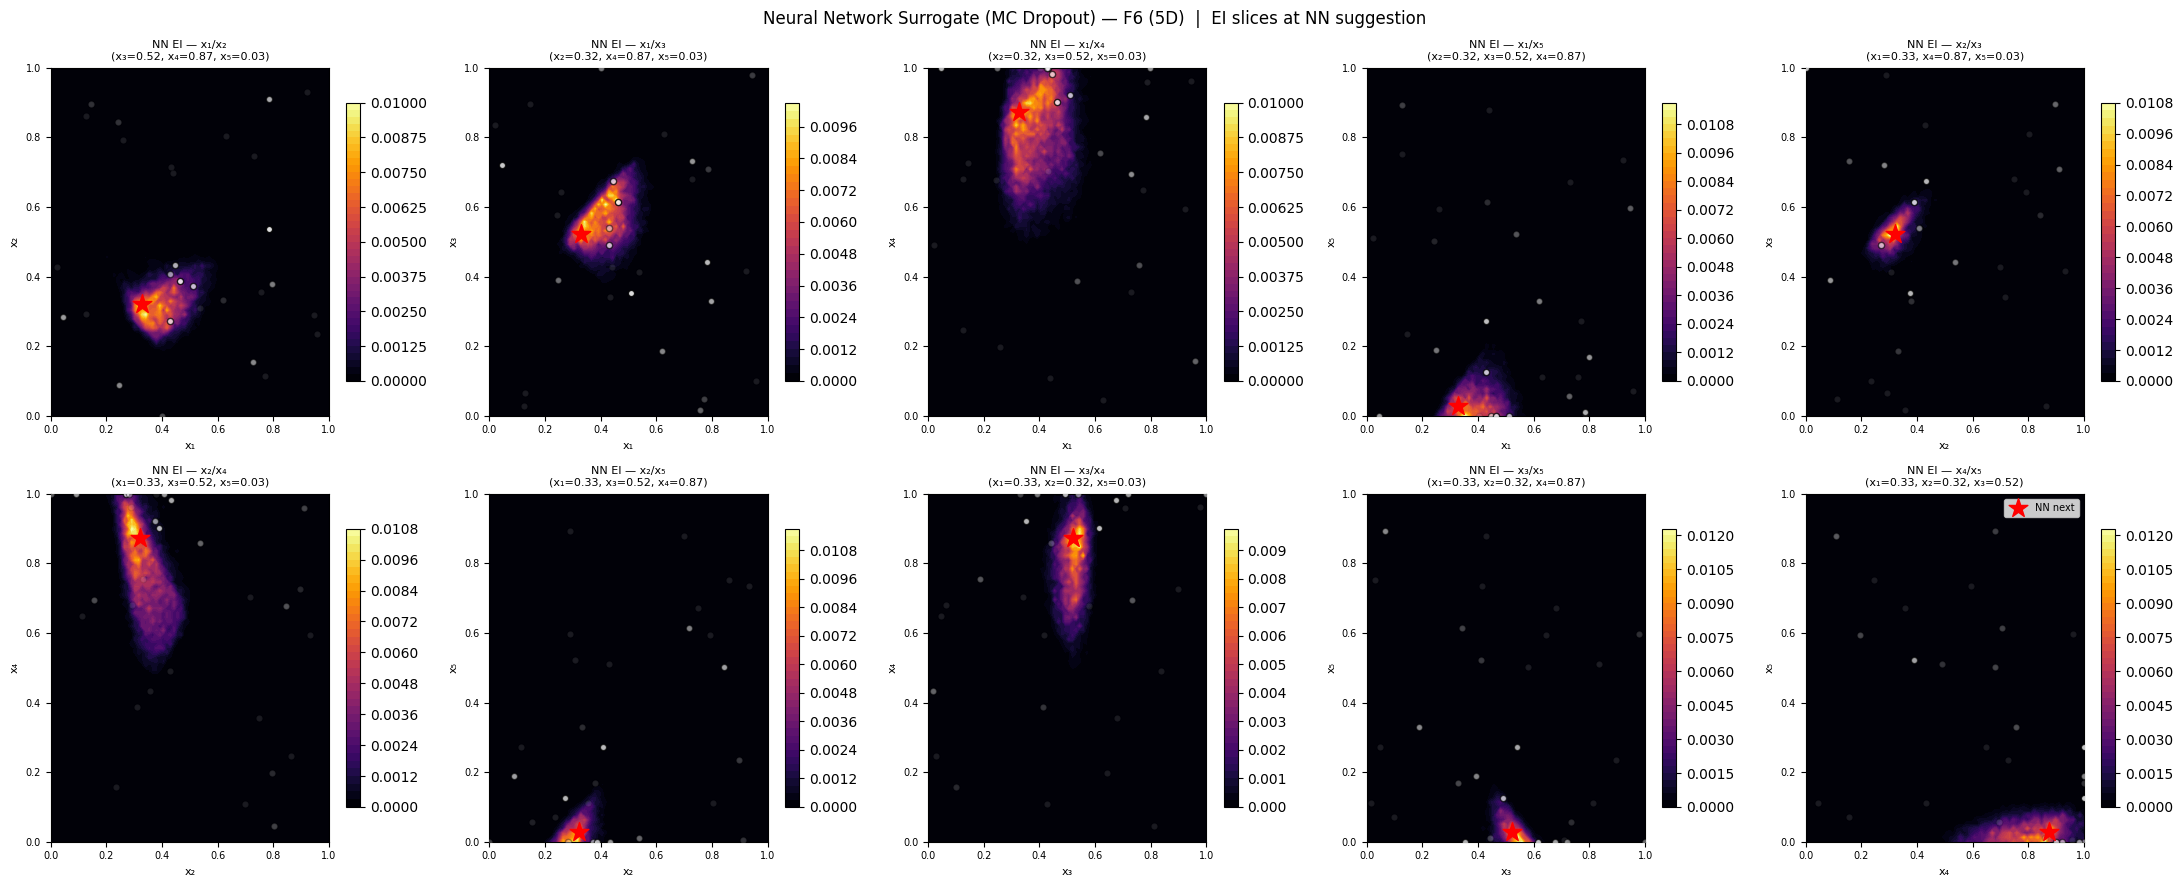

In [13]:
resolution = 80    # matches GP slice resolution for 5D (10 panels)
grid_1d    = np.linspace(0, 1, resolution)
G1, G2     = np.meshgrid(grid_1d, grid_1d)
flat1, flat2 = G1.ravel(), G2.ravel()

dim_labels = ["x₁", "x₂", "x₃", "x₄", "x₅"]
dim_pairs  = list(combinations(range(5), 2))   # all 10 pairs

fig, axes = plt.subplots(2, 5, figsize=(22, 9))
axes_flat  = axes.ravel()
fig.suptitle(
    "Neural Network Surrogate (MC Dropout) — F6 (5D)  |  EI slices at NN suggestion",
    fontsize=12
)

for ax, (d0, d1) in zip(axes_flat, dim_pairs):
    fixed_dims = [d for d in range(5) if d not in (d0, d1)]

    X_grid        = np.tile(best_x_nn, (resolution * resolution, 1))
    X_grid[:, d0] = flat1
    X_grid[:, d1] = flat2

    ei_vals = expected_improvement_nn(
        X_grid, nn_model, scaler_nn, y_nn_mean, y_nn_std, y_obs.max(), xi=xi_nn, n_mc=200
    ).reshape(resolution, resolution)

    im = ax.contourf(G1, G2, ei_vals, levels=40, cmap="inferno")
    fig.colorbar(im, ax=ax, shrink=0.8)

    dist   = np.mean([np.abs(X_obs[:, fd] - best_x_nn[fd]) for fd in fixed_dims], axis=0)
    alphas = np.clip(1.0 - dist / 0.3, 0.1, 1.0)
    for xi_o, yi_o, a in zip(X_obs[:, d0], X_obs[:, d1], alphas):
        ax.scatter(xi_o, yi_o, c="white", edgecolors="black",
                   s=20, alpha=float(a), zorder=5)

    ax.scatter(best_x_nn[d0], best_x_nn[d1], c="red", marker="*",
               s=200, zorder=6, label="NN next")

    fix_str = ", ".join(f"{dim_labels[fd]}={best_x_nn[fd]:.2f}" for fd in fixed_dims)
    ax.set_title(f"NN EI — {dim_labels[d0]}/{dim_labels[d1]}\n({fix_str})", fontsize=8)
    ax.set_xlabel(dim_labels[d0], fontsize=8)
    ax.set_ylabel(dim_labels[d1], fontsize=8)
    ax.tick_params(labelsize=7)

axes_flat[-1].legend(loc="upper right", fontsize=7)
plt.tight_layout()
plt.savefig("nn_surrogate_f6.png", dpi=150)
plt.show()

## 14. Compare all three models: GP vs SVM vs NN

We compare the **EI score** and **suggested next point** from each surrogate:

| Model | Surrogate type | Uncertainty source |
|---|---|---|
| **GP** | Matérn 5/2 kernel | Bayesian posterior (exact) |
| **SVM** | RBF classifier | P(high region) — filters candidates |
| **NN** | MC-Dropout MLP | 200 stochastic forward passes |

A bar chart visualises the EI values directly, and pairwise distances quantify agreement between the three suggestions.

Model                                                                     Suggested x           EI
----------------------------------------------------------------------------------------------------
GP (unconstrained)                      [0.457478, 0.378088, 0.654848, 0.812513, 0.0]     0.014005
SVM-constrained                          [0.45757, 0.378217, 0.654116, 0.813972, 0.0]     0.014735
NN (MC Dropout)                     [0.328036, 0.321183, 0.522175, 0.87377, 0.027754]     0.007796

GP  ↔ SVM distance : 0.0016
GP  ↔ NN  distance : 0.2052
SVM ↔ NN  distance : 0.2044

⚠️  Mild disagreement — GP posterior is most principled; prefer GP suggestion.


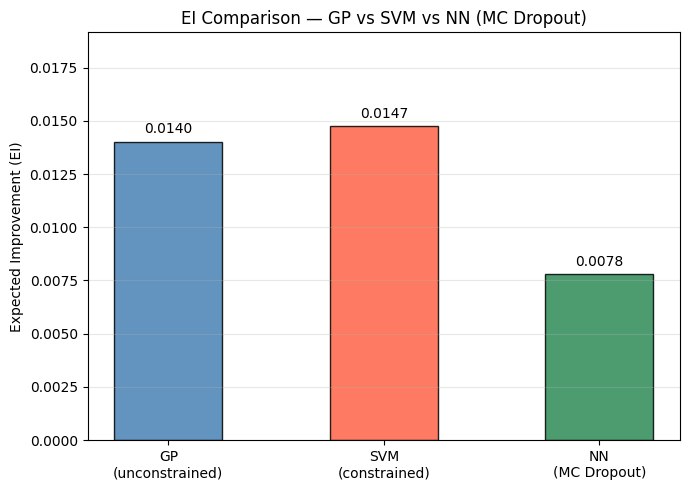

In [14]:
# ── Summary table ─────────────────────────────────────────────────────────────
print(f"{'Model':<24} {'Suggested x':>60}   {'EI':>10}")
print("-" * 100)
print(f"{'GP (unconstrained)':<24} {str(np.round(x_next, 6).tolist()):>60}   {score:>10.6f}")
print(f"{'SVM-constrained':<24} {str(np.round(best_x_svm, 6).tolist()):>60}   {best_score_svm:>10.6f}")
print(f"{'NN (MC Dropout)':<24} {str(np.round(best_x_nn, 6).tolist()):>60}   {best_score_nn:>10.6f}")

# ── Pairwise distances ────────────────────────────────────────────────────────
dist_gp_svm = np.linalg.norm(x_next - best_x_svm)
dist_gp_nn  = np.linalg.norm(x_next - best_x_nn)
dist_svm_nn = np.linalg.norm(best_x_svm - best_x_nn)

print(f"\nGP  ↔ SVM distance : {dist_gp_svm:.4f}")
print(f"GP  ↔ NN  distance : {dist_gp_nn:.4f}")
print(f"SVM ↔ NN  distance : {dist_svm_nn:.4f}")

# ── Consensus check ───────────────────────────────────────────────────────────
suggestions = [x_next, best_x_svm, best_x_nn]
centroid    = np.mean(suggestions, axis=0)
max_dev     = max(np.linalg.norm(s - centroid) for s in suggestions)

if max_dev < 0.05:
    print("\n✅ All three models agree — very high confidence in this region.")
elif max_dev < 0.15:
    print("\n⚠️  Mild disagreement — GP posterior is most principled; prefer GP suggestion.")
else:
    print("\n❗ Strong disagreement — models see different promising regions; trust the GP.")

# ── Bar chart: EI scores across the three surrogates ─────────────────────────
labels_bar    = ["GP\n(unconstrained)", "SVM\n(constrained)", "NN\n(MC Dropout)"]
ei_scores_bar = [score, best_score_svm, best_score_nn]
colors_bar    = ["steelblue", "tomato", "seagreen"]

fig, ax = plt.subplots(figsize=(7, 5))
bars = ax.bar(labels_bar, ei_scores_bar, color=colors_bar,
              edgecolor="black", alpha=0.85, width=0.5)
ax.bar_label(bars, fmt="%.4f", padding=4, fontsize=10)
ax.set_ylabel("Expected Improvement (EI)")
ax.set_title("EI Comparison — GP vs SVM vs NN (MC Dropout)")
ax.set_ylim(0, max(ei_scores_bar) * 1.3)
ax.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.savefig("ei_comparison_three_models_f6.png", dpi=150)
plt.show()

## 15. Hyperparameter Sensitivity — ξ (xi) Exploration (Module 18)

Module 18 identifies **ξ (xi)** as the key hyperparameter of the EI acquisition function controlling the exploration–exploitation trade-off. Rather than relying solely on the adaptive decay schedule, this section applies a **coarse grid search** over ξ — the simplest tuning strategy from Mini-lesson 18.5.

By scanning ξ ∈ {0.001 … 0.5} with the GP already fitted on all 5D observations, we can:
- Confirm the adaptive ξ is in a sensible range for the current dataset
- See how sensitive the suggested query is to this hyperparameter
- Decide whether to override the schedule if the function appears nearly converged (small ξ) or still widely uncertain (large ξ)

In [15]:
# ── ξ (xi) grid search — treating xi as a hyperparameter to tune ──────────────────
print('GP suggestion sensitivity to xi (exploration-exploitation hyperparameter):')
print(f"{'xi':>8}  {'EI score':>12}  Suggested x (CAPSTONE format)")
print('-' * 85)

xi_grid    = [0.001, 0.01, 0.05, 0.1, 0.5]
xi_current = adaptive_xi(N_ITER, xi_init=XI_INIT, decay=XI_DECAY)

for xi_test in xi_grid:
    sampler_s  = qmc.Sobol(d=n_dim, scramble=True, seed=SEED + 888)
    X_c_s      = sampler_s.random(8_192)          # 2^13 quick scan
    scores_s   = expected_improvement(X_c_s, gp, y_obs.max(), xi=xi_test)
    starts_s   = X_c_s[np.argsort(scores_s)[-5:]]
    obj_s      = lambda x, xi=xi_test: -expected_improvement(x, gp, y_obs.max(), xi=xi).item()
    bx_s, bs_s = None, -np.inf
    for x0 in starts_s:
        r = minimize(obj_s, x0=x0, bounds=[(0, 1)] * n_dim, method='L-BFGS-B')
        if -r.fun > bs_s: bs_s = -r.fun; bx_s = r.x
    capstone_s = '-'.join(f'{v:.6f}' for v in bx_s)
    marker     = '  <- adaptive (current)' if abs(xi_test - xi_current) < 0.02 else ''
    print(f'  {xi_test:>6.3f}  {bs_s:>12.6f}  {capstone_s}{marker}')

print(f'\nAdaptive xi at iteration {N_ITER}: {xi_current:.5f}  '
      f'(xi_init={XI_INIT}, decay={XI_DECAY}^{N_ITER})')

GP suggestion sensitivity to xi (exploration-exploitation hyperparameter):
      xi      EI score  Suggested x (CAPSTONE format)
-------------------------------------------------------------------------------------
   0.001      0.019197  0.458004-0.378882-0.650344-0.821565-0.000000  <- adaptive (current)
   0.010      0.016933  0.457809-0.378564-0.652123-0.817962-0.000000  <- adaptive (current)
   0.050      0.009290  0.456629-0.377083-0.660866-0.800803-0.000000
   0.100      0.003982  0.454343-0.375150-0.673896-0.777251-0.000000
   0.500      0.000057  0.390139-0.000000-1.000000-0.000000-0.000000

Adaptive xi at iteration 10: 0.01969  (xi_init=0.1, decay=0.85^10)


## 16. GP Kernel Diagnostics (Module 18)

The GP kernel hyperparameters are fitted by maximising the log-marginal-likelihood. Inspecting them connects to Module 18's insight that **length scales act as feature importance scores**:

- **Small length scale** → function changes quickly along that axis → high sensitivity → important dimension
- **Large length scale** → function is nearly flat along that axis → low sensitivity → potentially irrelevant

This mirrors Module 18's note that random search works well when only a few hyperparameters heavily influence performance — the same may be true of our 5D function's input dimensions. A large length-scale disparity is a signal to focus future queries on the most sensitive dimensions.

Fitted GP kernel hyperparameters (F6, 5D):
  Amplitude  s2   : 6.7917
  Noise level     : 3.57e-02

Per-dimension length scales:
  x1:    1.2686  XXXXXXXXXXXX
  x2:    1.5548  XXXXXXXXXXXX
  x3:    2.0989  XXXXXXXXXXXXX
  x4:    2.1633  XXXXXXXXXXXXX
  x5:    3.4517  XXXXXXXXXXXXXX

Most  sensitive dim : x1 (ls=1.2686)
Least sensitive dim : x5 (ls=3.4517)

[OK] Length scale ratio 2.7x -- all dimensions contribute similarly.


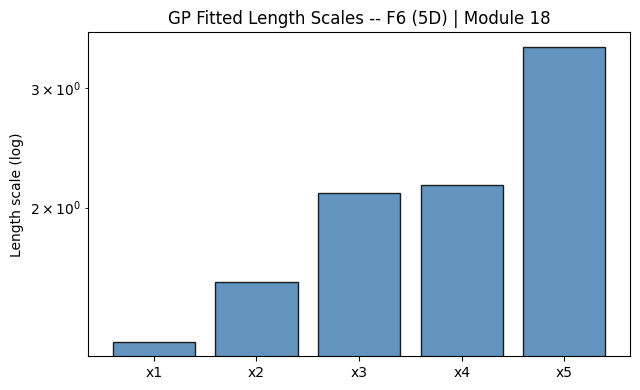

In [16]:
# ── GP fitted kernel hyperparameters ─────────────────────────────────────────────
fitted_ls = gp.kernel_.k1.k2.length_scale
noise_lv  = gp.kernel_.k2.noise_level
amplitude = gp.kernel_.k1.k1.constant_value
ls_arr    = np.array(fitted_ls)
dim_lbls  = [f'x{i+1}' for i in range(n_dim)]

print(f'Fitted GP kernel hyperparameters (F6, {n_dim}D):')
print(f'  Amplitude  s2   : {amplitude:.4f}')
print(f'  Noise level     : {noise_lv:.2e}')
print('\nPer-dimension length scales:')
for lbl, ls in zip(dim_lbls, ls_arr):
    bar = 'X' * max(1, min(int(np.log10(ls + 1e-8) * 5 + 12), 35))
    print(f'  {lbl}: {ls:9.4f}  {bar}')

if n_dim >= 3:
    idx_min, idx_max = ls_arr.argmin(), ls_arr.argmax()
    ratio = ls_arr[idx_max] / (ls_arr[idx_min] + 1e-8)
    print(f'\nMost  sensitive dim : {dim_lbls[idx_min]} (ls={ls_arr[idx_min]:.4f})')
    print(f'Least sensitive dim : {dim_lbls[idx_max]} (ls={ls_arr[idx_max]:.4f})')
    if ratio > 10:
        print(f'\n[!] Length scale ratio {ratio:.0f}x -- function may be effectively '
              f'lower-dimensional. Focus future queries around {dim_lbls[idx_min]}.')
    else:
        print(f'\n[OK] Length scale ratio {ratio:.1f}x -- all dimensions contribute similarly.')

fig, ax = plt.subplots(figsize=(max(6, n_dim * 1.3), 4))
ax.bar(dim_lbls, ls_arr, color='steelblue', edgecolor='black', alpha=0.85)
ax.set_yscale('log')
ax.set_ylabel('Length scale (log)')
ax.set_title(f'GP Fitted Length Scales -- F6 ({n_dim}D) | Module 18')
ax.grid(True, axis='y', alpha=0.4)
plt.tight_layout()
plt.savefig('length_scales_module18_f6.png', dpi=150)
plt.show()

## 17. Convergence Plot

After running multiple iterations with real evaluations, this cell plots the **best observed value over time**.

Since all F6 outputs are negative, the curve will rise from below toward zero as the optimizer improves. A well-functioning BO loop should show a monotonically non-decreasing curve — if it stays flat for many iterations, the optimizer may be stuck in a local region and increasing `xi` or switching to UCB may help.

Uncomment and run after completing multiple BO iterations.

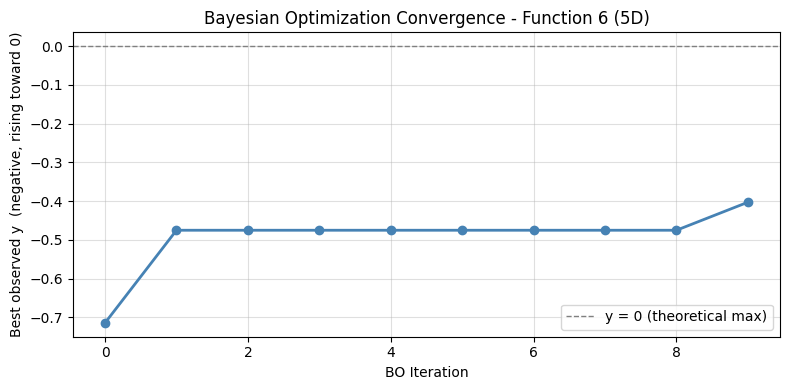

In [17]:
plt.figure(figsize=(8, 4))
plt.plot(range(len(history_best)), history_best, marker="o", linewidth=2, color="steelblue")
plt.axhline(0, color="gray", linestyle="--", linewidth=1, label="y = 0 (theoretical max)")
plt.xlabel("BO Iteration")
plt.ylabel("Best observed y  (negative, rising toward 0)")
plt.title("Bayesian Optimization Convergence - Function 6 (5D)")
plt.legend()
plt.grid(True, alpha=0.4)
plt.tight_layout()
plt.savefig("convergence_f6.png", dpi=150)
plt.show()